# Config

In [1]:
import numpy as np
import sys
import pandas as pd

In [2]:
Proj_path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/FG_2026_Projections'

In [3]:
League_path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Imaginary_Hammers'

In [4]:
Player_ID_Map_Path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Player_ID_Map/Latest_Player_ID_Map.csv'

In [5]:
Player_ID_Map_df = pd.read_csv(Player_ID_Map_Path)
Player_ID_Map_df['FG ID'] = Player_ID_Map_df['FG ID'].astype(str)
Player_ID_Map_df['FG ID'] = Player_ID_Map_df['FG ID'].fillna(Player_ID_Map_df['FG Minor ID'])
Player_ID_Map_df['FG ID'] = Player_ID_Map_df['FG ID'].str.replace('.0','')
Player_ID_Map_df['Ottoneu ID'] = Player_ID_Map_df['Ottoneu ID'].astype(str)
Player_ID_Map_df['Ottoneu ID'] = Player_ID_Map_df['Ottoneu ID'].str.replace('.0','')

In [6]:
sys.path.append('../')

In [7]:
Latest_Proj = {
    'Hitter':'Mar21_2026',
    'Pitcher':'Mar21_2026'
}

In [8]:
SGP_Calc_date = 'Mar21_2026'

In [9]:
#Filter Pitchers
IP_min = 40.

#Filter Hitters
AB_min = 100.

In [10]:
Players_on_rosters_not_at_min = [
    '33677',
    '34103',
    '38456'
]

In [11]:
Unknown_missing = [
    '9668',
    '22426',
    '45769',
    '45789',
    '37480',
    '45947',
    '18116',
    '42741',
    '45739',
    '45713'
]

In [12]:
publish_Val_Update = {
    'Hitter':True,
    'Pitcher':True
}

In [13]:

Hitter_Projections_df = pd.read_csv(f"{Proj_path}/my_Hitter_Proj_{Latest_Proj['Hitter']}.csv")
Pitcher_Projections_df = pd.read_csv(f"{Proj_path}/my_Pitcher_Proj_{Latest_Proj['Pitcher']}.csv")

Hitter_Projections_df['FG ID'] = Hitter_Projections_df['FG ID'].astype(str)
Hitter_Projections_df['FG ID'] = Hitter_Projections_df['FG ID'].str.replace('.0','')
Hitter_Projections_df['Ottoneu ID'] = Hitter_Projections_df['Ottoneu ID'].astype(str)
Hitter_Projections_df['Ottoneu ID'] = Hitter_Projections_df['Ottoneu ID'].str.replace('.0','')
Pitcher_Projections_df['FG ID'] = Pitcher_Projections_df['FG ID'].astype(str)
Pitcher_Projections_df['FG ID'] = Pitcher_Projections_df['FG ID'].str.replace('.0','')
Pitcher_Projections_df['Ottoneu ID'] = Pitcher_Projections_df['Ottoneu ID'].astype(str)
Pitcher_Projections_df['Ottoneu ID'] = Pitcher_Projections_df['Ottoneu ID'].str.replace('.0','')


In [14]:
Hitter_Projections_df[Hitter_Projections_df['Ottoneu ID'] == '33677']

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,RBI,BB,HBP,SF,WAR,ADP,POS,Ottoneu ID,Ottoneu Positions,Name
462,25971,CHC,11.7627,36.41036,33.50236,7.69398,5.13953,1.901068,0.04203,0.611382,...,4.30655,2.724862,0.09081,0.071038,0.251014,999.0,['OF'],33677,OF,Kevin Alcantara


In [15]:
Hitter_Projections_df.head()

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,RBI,BB,HBP,SF,WAR,ADP,POS,Ottoneu ID,Ottoneu Positions,Name
0,10028,CHC,0.00000,1.0000,1.0000,0.00000,0.00000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.001407,999.000000,['C'],18048,C,Christian Bethancourt
1,10155,LAA,122.63920,525.3260,444.6746,106.01270,60.76846,17.718100,1.799282,25.726840,...,68.54890,70.244320,6.435478,3.700210,2.555656,178.910004,"['DH', 'OF']",6305,OF,Mike Trout
2,10243,NYY,35.85476,144.5400,132.6196,31.55082,19.18724,6.811464,0.400766,5.551346,...,17.61502,9.106418,1.220332,1.145086,0.188103,999.000000,"['DH', 'OF']",6320,OF,Randal Grichuk
3,10324,PIT,123.24320,522.2472,453.2730,110.13880,69.28562,19.842960,0.108619,20.901560,...,66.68648,61.832180,3.001938,4.031374,0.927671,372.309998,"['DH', 'OF']",6130,Util,Marcell Ozuna
4,10472,LAD,47.12238,186.0596,169.1838,37.58262,24.30588,8.091872,0.086417,5.498438,...,21.55730,13.425500,1.007362,1.602070,0.117489,999.000000,"['1B', 'OF']",11508,1B/2B/3B/OF/RP,Enrique Hernandez


In [16]:
Pitcher_Projections_df[Pitcher_Projections_df['FG ID'].isin([key for key, val in Pitcher_Projections_df['FG ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,Team,W,L,QS,G,GS,SV,HLD,IP,...,HR,BB,HBP,SO,WAR,ADP,POS,Ottoneu ID,Ottoneu Positions,Name


In [17]:
Hitter_Projections_df = Hitter_Projections_df.merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='inner')
Pitcher_Projections_df = Pitcher_Projections_df.merge(Player_ID_Map_df[['FG ID','Ottoneu ID','Ottoneu Positions','Name']],how='inner')

In [18]:
Hitter_Projections_df[Hitter_Projections_df['Ottoneu ID'] == '33677']

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,RBI,BB,HBP,SF,WAR,ADP,POS,Ottoneu ID,Ottoneu Positions,Name
462,25971,CHC,11.7627,36.41036,33.50236,7.69398,5.13953,1.901068,0.04203,0.611382,...,4.30655,2.724862,0.09081,0.071038,0.251014,999.0,['OF'],33677,OF,Kevin Alcantara


In [19]:
Hitter_Projections_df[Hitter_Projections_df['Ottoneu ID'].isin([key for key, val in Hitter_Projections_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,RBI,BB,HBP,SF,WAR,ADP,POS,Ottoneu ID,Ottoneu Positions,Name


In [20]:
Pitcher_Projections_df[Pitcher_Projections_df['Ottoneu ID'].isin([key for key, val in Pitcher_Projections_df['Ottoneu ID'].value_counts().to_dict().items() if val > 1])].sort_values('Name')

,FG ID,Team,W,L,QS,G,GS,SV,HLD,IP,...,HR,BB,HBP,SO,WAR,ADP,POS,Ottoneu ID,Ottoneu Positions,Name


<Axes: >

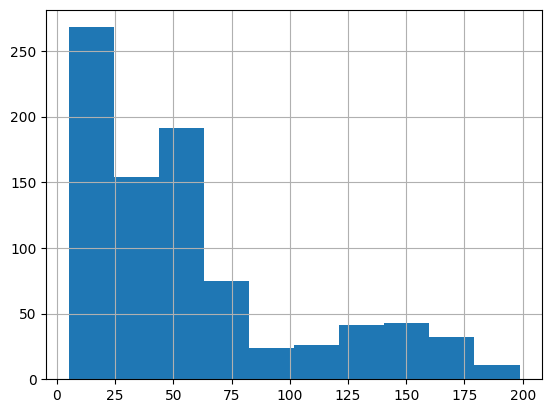

In [21]:
Pitcher_Projections_df[Pitcher_Projections_df['IP'] > 5.]['IP'].hist()

In [22]:
Hitter_Projections_df[Hitter_Projections_df['Ottoneu ID'].isin(Players_on_rosters_not_at_min)][['Name','Ottoneu ID','AB']]

,Name,Ottoneu ID,AB
462,Kevin Alcantara,33677,33.50236
797,Emmanuel Rodriguez,38456,54.46000


In [23]:
Pitcher_Projections_df[Pitcher_Projections_df['Ottoneu ID'].isin(Players_on_rosters_not_at_min)][['Name','Ottoneu ID','IP']]

,Name,Ottoneu ID,IP
507,Ronny Henriquez,34103,1.27829


In [24]:

#Filter Pitchers
Pitcher_Projections_df = Pitcher_Projections_df[
    (Pitcher_Projections_df['IP'] > IP_min) |
    (Pitcher_Projections_df['Ottoneu ID'].isin(Players_on_rosters_not_at_min))
    ]

#Filter Hitters
Hitter_Projections_df = Hitter_Projections_df[
    (Hitter_Projections_df['AB'] > AB_min) |
    (Hitter_Projections_df['Ottoneu ID'].isin(Players_on_rosters_not_at_min))
    ]

In [25]:
Hitter_Projections_df[Hitter_Projections_df['Ottoneu ID'].isin(Players_on_rosters_not_at_min)][['Name','Ottoneu ID']]

,Name,Ottoneu ID
462,Kevin Alcantara,33677
797,Emmanuel Rodriguez,38456


In [26]:
Pitcher_Projections_df[Pitcher_Projections_df['Ottoneu ID'].isin(Players_on_rosters_not_at_min)][['Name','Ottoneu ID']]

,Name,Ottoneu ID
507,Ronny Henriquez,34103


In [27]:
Hitter_Projections_df[Hitter_Projections_df['Ottoneu ID'].isin(Unknown_missing)][['Name','Ottoneu ID']]

,Name,Ottoneu ID
23,Eugenio Suarez,9668
474,Kyle Stowers,37480
1921,JJ Wetherholt,45713
1972,Ryan Waldschmidt,45789
2042,Carson Benge,45947
2148,Braden Montgomery,45739
2210,Konnor Griffin,45769


In [28]:
Hitter_Projections_df[Hitter_Projections_df['Ottoneu ID'].isin(Unknown_missing)][['Name','Ottoneu ID']]

,Name,Ottoneu ID
23,Eugenio Suarez,9668
474,Kyle Stowers,37480
1921,JJ Wetherholt,45713
1972,Ryan Waldschmidt,45789
2042,Carson Benge,45947
2148,Braden Montgomery,45739
2210,Konnor Griffin,45769


In [29]:
from Stat_modules import OBP,SLG,HR9,ERA,WHIP,TB
Hitter_Projections_df['OBP'] = OBP(Hitter_Projections_df['H'],Hitter_Projections_df['BB'],Hitter_Projections_df['HBP'],Hitter_Projections_df['SF'],Hitter_Projections_df['AB'])
Hitter_Projections_df['TB'] = TB(Hitter_Projections_df['1B'],Hitter_Projections_df['2B'],Hitter_Projections_df['3B'],Hitter_Projections_df['HR'])
Hitter_Projections_df['SLG'] = SLG(Hitter_Projections_df['TB'],Hitter_Projections_df['AB'])
Pitcher_Projections_df['HR9'] = HR9(Pitcher_Projections_df['HR'],Pitcher_Projections_df['IP'])
Pitcher_Projections_df['ERA'] = ERA(Pitcher_Projections_df['ER'],Pitcher_Projections_df['IP'])
Pitcher_Projections_df['WHIP'] = WHIP(Pitcher_Projections_df['BB'],Pitcher_Projections_df['H'],Pitcher_Projections_df['IP'])

In [30]:
#Jan23 2025 Roster totals
Replacement_Level = {
    'C':24,
    '1B':25,
    '2B':27,
    'SS':44,
    '3B':19,
    'OF':89,
    'Util':233,
    'SP':150,
    'RP':65,
    'P':215
}
Replacement_window = {
    'C':5,
    '1B':5,
    '2B':5,
    'SS':5,
    '3B':5,
    'OF':5,
    'Util':5,
    'SP':5,
    'RP':5,
    'P':5
}
Replacement_rank_stat = 'WAR'
Hitting_Pos = [
    'C',
    '1B',
    '2B',
    'SS',
    '3B',
    'OF',
    'Util'
]
Pitching_Pos = [
    'SP',
    'RP',
    'P'
]

All_Pos = Hitting_Pos + Pitching_Pos

In [31]:
#Scoring Categories
Count_Scoring_Categories_Batting = [
    'R',
    'HR'
]
Rate_Scoring_Categories_Batting = [
    'OBP',
    'SLG'
]
Count_Scoring_Categories_Pitching = [
    'SO'
]
Rate_Scoring_Categories_Pitching = [
    "HR9",
    "ERA",
    "WHIP"
]
Num_teams = 12.
Team_budget = 400.
Hitter_sal_split = 0.53
League_budget = Team_budget*Num_teams
Hitter_budget = League_budget*Hitter_sal_split
Pitcher_budget = League_budget*(1.-Hitter_sal_split)
Scoring_Categories_Batting = Count_Scoring_Categories_Batting + Rate_Scoring_Categories_Batting
Scoring_Categories_Pitching = Count_Scoring_Categories_Pitching + Rate_Scoring_Categories_Pitching
Scoring_Categories = Scoring_Categories_Batting + Scoring_Categories_Pitching

In [32]:
Hitter_budget

2544.0

In [33]:
Player_id_cols = [
    'FG ID','Ottoneu ID','Name','Ottoneu Positions','Team'
]
Hitter_Count_Stats = [
    'G','PA','AB','H','1B','2B','3B','HR','R','RBI','BB','HBP','SF','WAR','ADP'
]
Pitcher_Count_Stats = [
    'W', 'L', 'QS', 'G', 'GS', 'SV', 'HLD', 'IP', 'TBF', 'H', 'R', 'ER', 'HR', 'BB', 'HBP', 'SO','WAR','ADP'
]

In [34]:
import json
with open(League_path+'/SGP_Denom_dict.json','r') as f:
    SGP_Denom = json.load(f)

In [35]:
SGP_Denom['SO'] = SGP_Denom['K']

# Replacement Level & Playable Average Stats

C
1B
2B
SS
3B
OF
Util


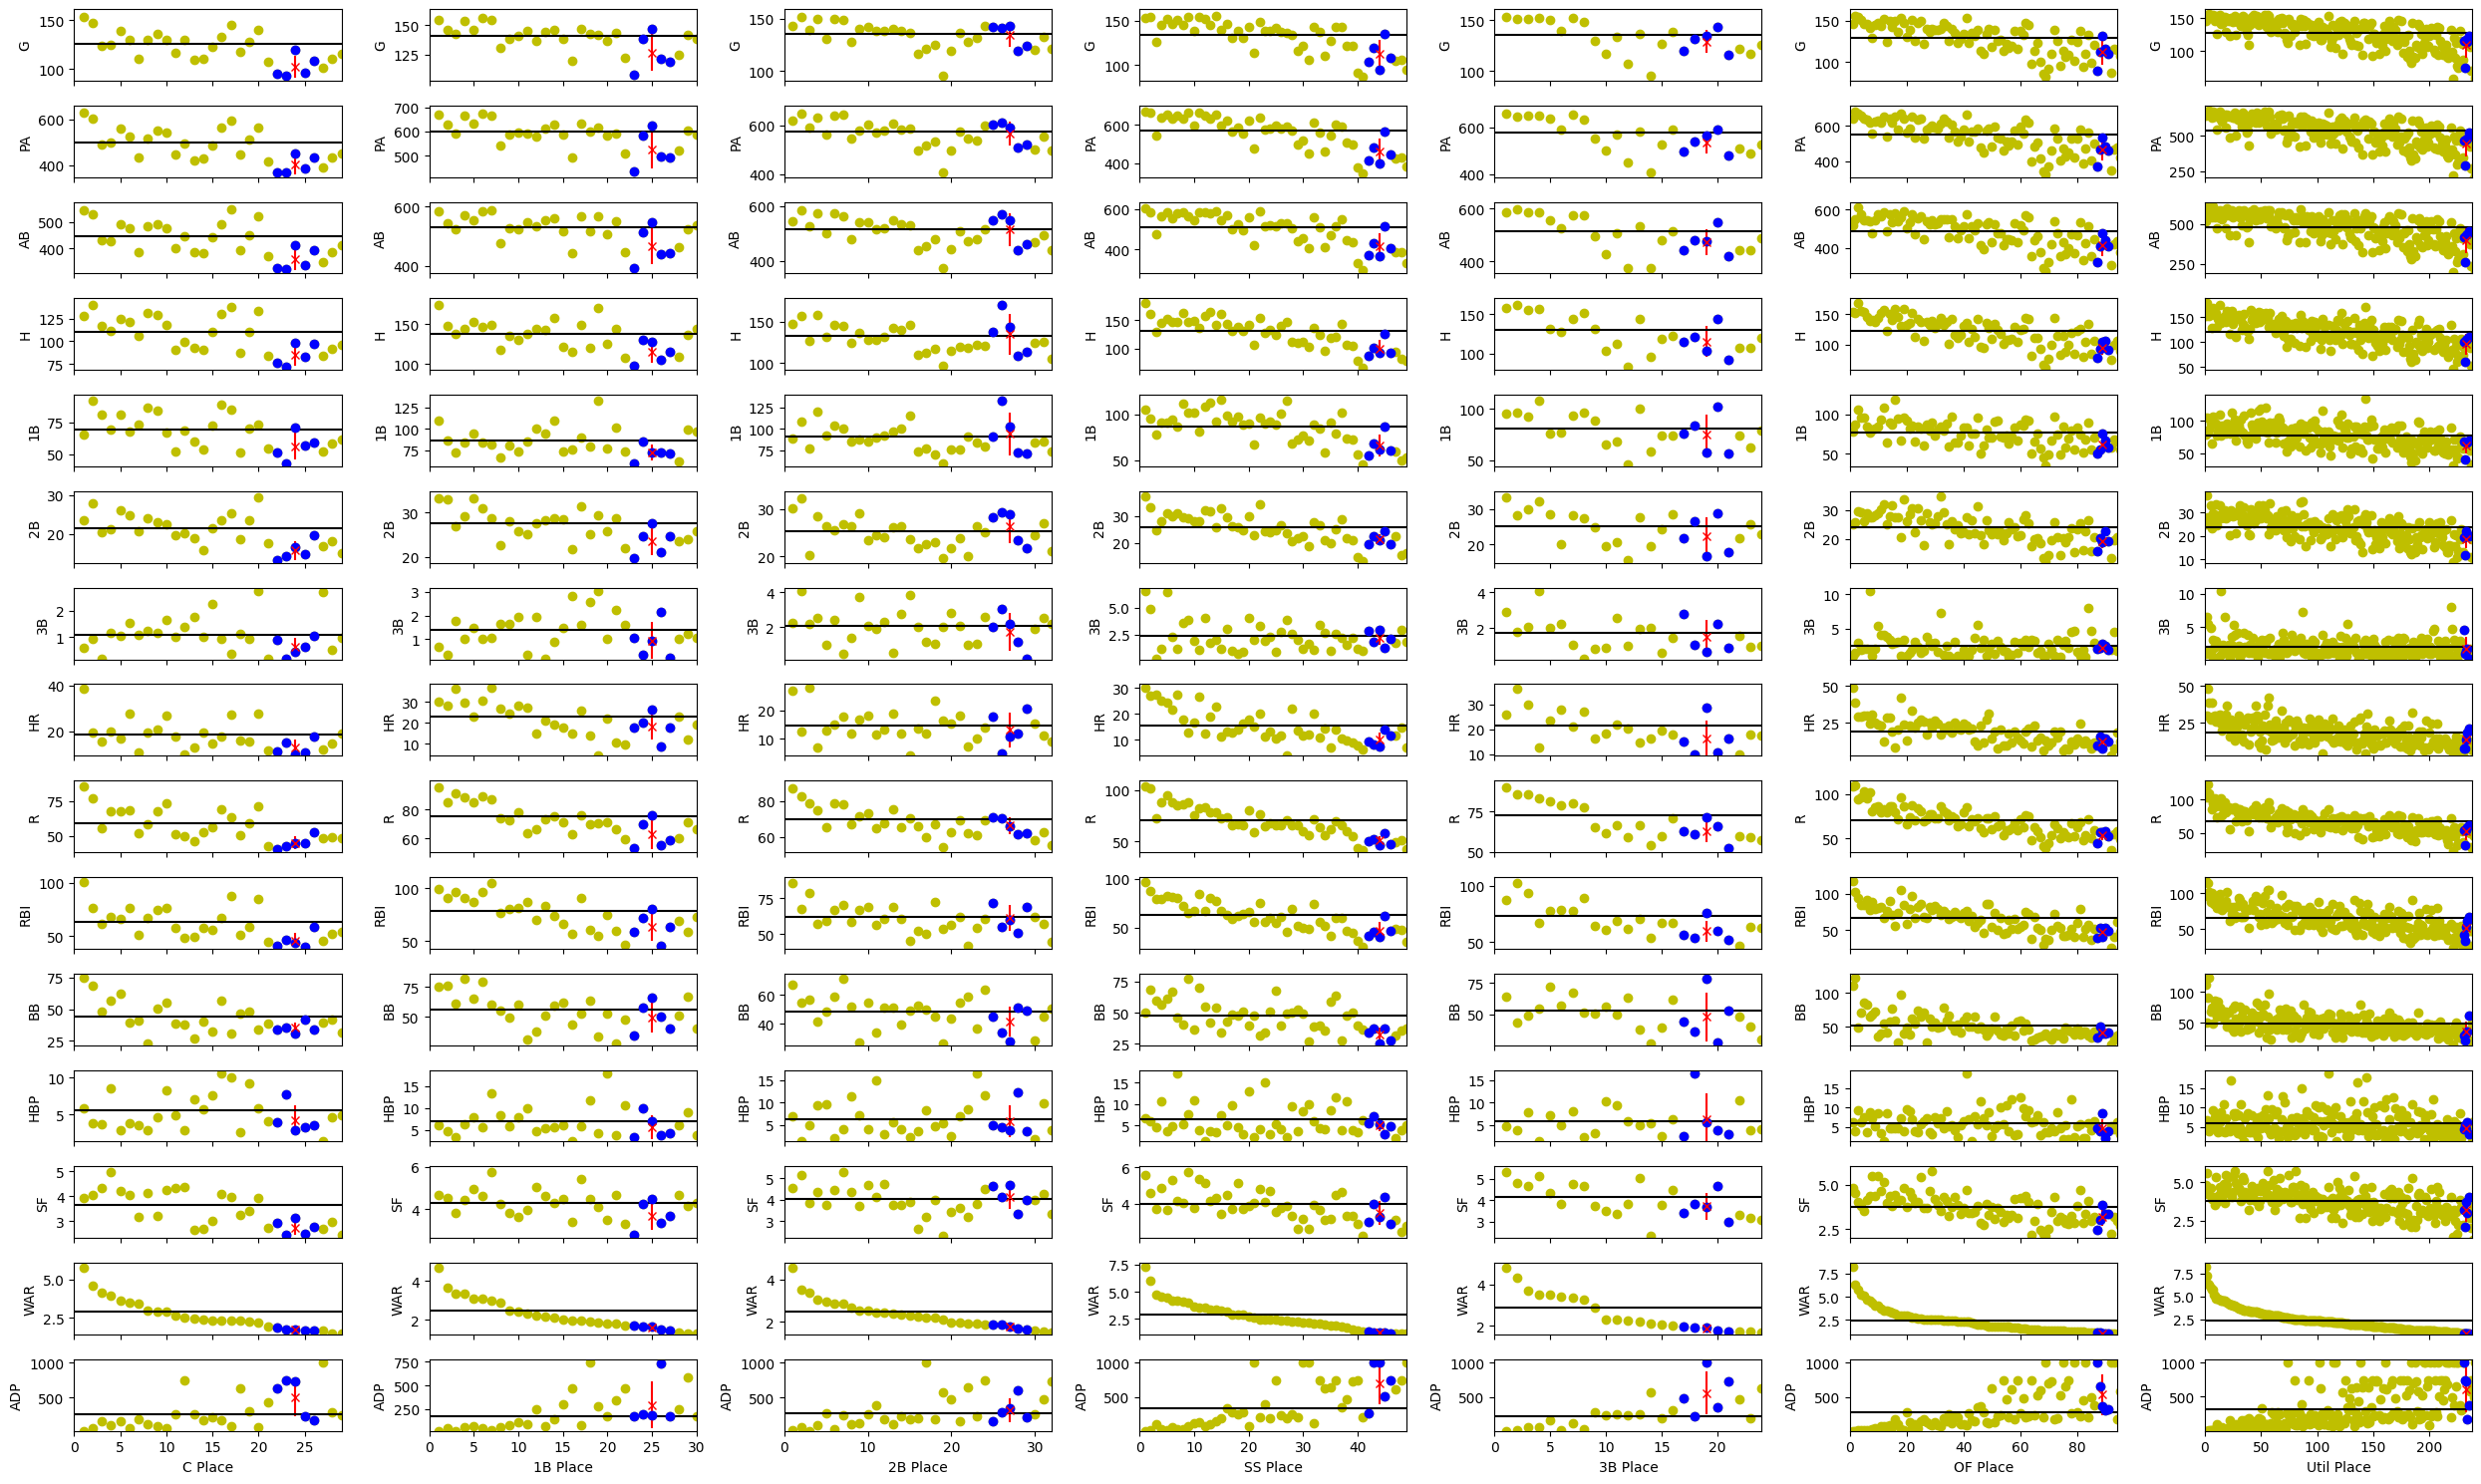

In [36]:
import matplotlib.pyplot as plt
import numpy as np

Hitting_Replacement_Stats_df = pd.DataFrame()
Hitting_Average_Stats_df = pd.DataFrame()

fig, axs = plt.subplots(len(Hitter_Count_Stats),len(Hitting_Pos),figsize=(25,15),sharex='col')
pos_idx = 0
for pos,repl_level_mid in Replacement_Level.items():
    if pos in Pitching_Pos:
        continue
    This_Pos_df = Hitter_Projections_df[Hitter_Projections_df['Ottoneu Positions'].apply(lambda x : f"{pos}" in x.strip('[]').split('/'))]
    if pos == 'Util':
        This_Pos_df = Hitter_Projections_df
    print(pos)
    This_Pos_df['Pos Place'] = This_Pos_df[Replacement_rank_stat].rank(method="dense", ascending=False)
    col_idx = 0
    x_max = repl_level_mid+Replacement_window[pos]


    for col in Hitter_Count_Stats:
        this_axis = axs[col_idx][pos_idx]
        this_axis.plot(This_Pos_df['Pos Place'],This_Pos_df[col], 'yo')

        Replacement_this_Pos_df = This_Pos_df[(This_Pos_df['Pos Place'] >= repl_level_mid-(Replacement_window[pos]/2)) \
                                              & (This_Pos_df['Pos Place'] <= repl_level_mid+(Replacement_window[pos]/2))
                                            ]
        mean = Replacement_this_Pos_df[col].mean()
        std = Replacement_this_Pos_df[col].std()
        Hitting_Replacement_Stats_df = pd.concat([
            Hitting_Replacement_Stats_df,
            pd.DataFrame([{
                'Ottoneu Positions':pos,
                'Stat':f'{col}',
                'mean':mean
            }])
        ])
        this_axis.errorbar(x=[Replacement_this_Pos_df[Replacement_this_Pos_df['Pos Place'] == repl_level_mid]['Pos Place']], y=[mean],yerr=[std], fmt='x',color='r')

        Playable_this_Pos_df = This_Pos_df[(This_Pos_df['Pos Place'] <= repl_level_mid)]
        coef = np.polyfit(Playable_this_Pos_df['Pos Place'],Playable_this_Pos_df[col],1)
        poly1d_fn = np.poly1d(coef) 
        Hitting_Average_Stats_df = pd.concat([
            Hitting_Average_Stats_df,
            pd.DataFrame([{
                'Ottoneu Positions':pos,
                'Stat':f'{col}',
                'mean':poly1d_fn(repl_level_mid/2)
            }])
        ])
        this_axis.axhline(poly1d_fn(repl_level_mid/2),color='k')

        this_axis.plot(Replacement_this_Pos_df['Pos Place'],Replacement_this_Pos_df[col], 'bo')
        

        this_axis.set_ylabel(col)
        ymin = 0.95*This_Pos_df[This_Pos_df['Pos Place'] <= x_max][col].min()
        ymax = 1.05*This_Pos_df[This_Pos_df['Pos Place'] <= x_max][col].max()
        this_axis.set_ylim([ymin,ymax])
        col_idx+=1
    pos_idx+=1
    this_axis.set_xlim([0,x_max])
    this_axis.set_xlabel(f'{pos} Place')
plt.tight_layout()

In [37]:
Hitting_Replacement_Stats_df

,Ottoneu Positions,Stat,mean
0,C,G,102.200936
0,C,PA,401.583960
0,C,AB,357.825800
0,C,H,85.269852
0,C,1B,56.137340
...,...,...,...
0,Util,BB,36.384912
0,Util,HBP,4.733547
0,Util,SF,3.191001
0,Util,WAR,0.938685


In [38]:
Hitting_Average_Stats_df

,Ottoneu Positions,Stat,mean
0,C,G,125.165246
0,C,PA,499.087791
0,C,AB,444.703175
0,C,H,110.772725
0,C,1B,69.644992
...,...,...,...
0,Util,BB,48.524364
0,Util,HBP,5.905520
0,Util,SF,3.793897
0,Util,WAR,2.417897


SP
RP
P


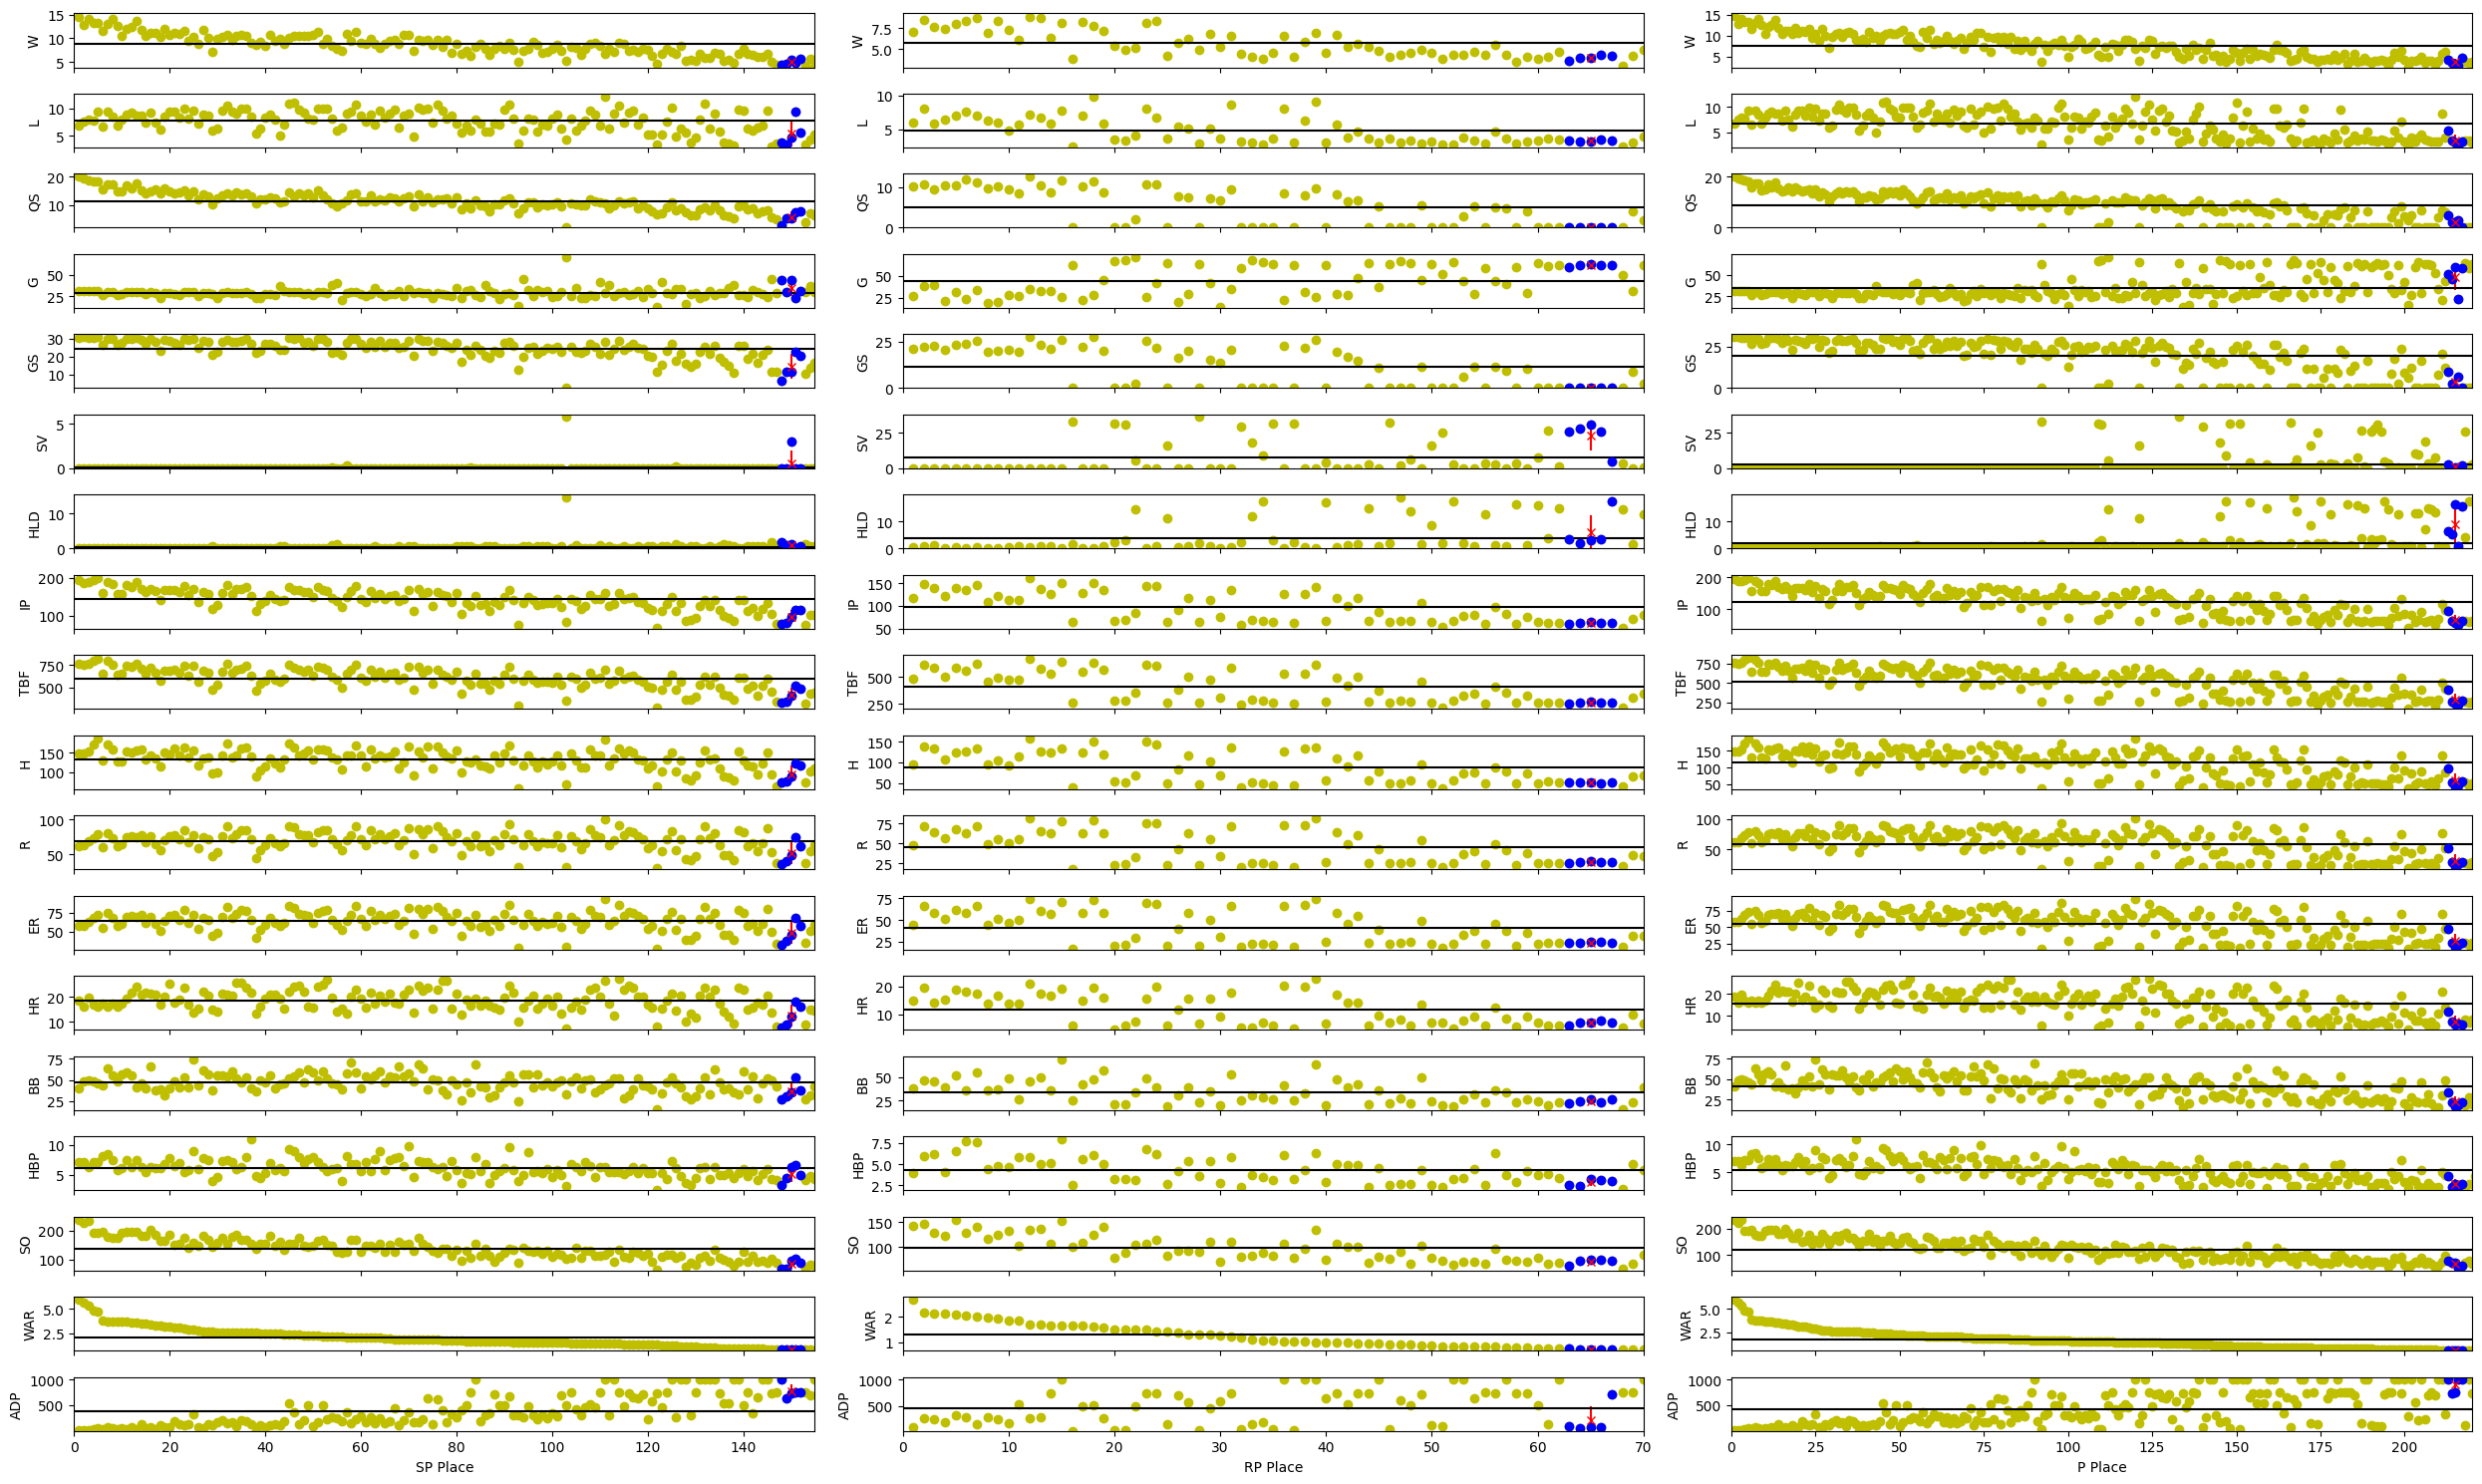

In [39]:
import matplotlib.pyplot as plt
import numpy as np

Pitching_Replacement_Stats_df = pd.DataFrame()
Pitching_Average_Stats_df = pd.DataFrame()

fig, axs = plt.subplots(len(Pitcher_Count_Stats),len(Pitching_Pos),figsize=(25,15),sharex='col')
pos_idx = 0
for pos,repl_level_mid in Replacement_Level.items():
    if pos in Hitting_Pos:
        continue
    This_Pos_df = Pitcher_Projections_df[Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : f"{pos}" in x.strip('[]').split('/'))]
    if pos == 'P':
        This_Pos_df = Pitcher_Projections_df
    print(pos)
    This_Pos_df['Pos Place'] = This_Pos_df[Replacement_rank_stat].rank(method="dense", ascending=False)
    col_idx = 0
    x_max = repl_level_mid+Replacement_window[pos]


    for col in Pitcher_Count_Stats:
        this_axis = axs[col_idx][pos_idx]
        this_axis.plot(This_Pos_df['Pos Place'],This_Pos_df[col], 'yo')

        Replacement_this_Pos_df = This_Pos_df[(This_Pos_df['Pos Place'] >= repl_level_mid-(Replacement_window[pos]/2)) \
                                              & (This_Pos_df['Pos Place'] <= repl_level_mid+(Replacement_window[pos]/2))
                                            ]
        mean = Replacement_this_Pos_df[col].mean()
        std = Replacement_this_Pos_df[col].std()
        Pitching_Replacement_Stats_df = pd.concat([
            Pitching_Replacement_Stats_df,
            pd.DataFrame([{
                'Ottoneu Positions':pos,
                'Stat':f'{col}',
                'mean':mean,
                'std':std
            }])
        ])
        this_axis.errorbar(x=[Replacement_this_Pos_df[Replacement_this_Pos_df['Pos Place'] == repl_level_mid]['Pos Place']], y=[mean],yerr=[std], fmt='x',color='r')

        Playable_this_Pos_df = This_Pos_df[(This_Pos_df['Pos Place'] <= repl_level_mid)]
        coef = np.polyfit(Playable_this_Pos_df['Pos Place'],Playable_this_Pos_df[col],1)
        poly1d_fn = np.poly1d(coef) 
        Pitching_Average_Stats_df = pd.concat([
            Pitching_Average_Stats_df,
            pd.DataFrame([{
                'Ottoneu Positions':pos,
                'Stat':f'{col}',
                'mean':poly1d_fn(repl_level_mid/2)
            }])
        ])
        this_axis.axhline(poly1d_fn(repl_level_mid/2),color='k')

        this_axis.plot(Replacement_this_Pos_df['Pos Place'],Replacement_this_Pos_df[col], 'bo')
        

        this_axis.set_ylabel(col)
        ymin = 0.95*This_Pos_df[This_Pos_df['Pos Place'] <= x_max][col].min()
        ymax = 1.05*This_Pos_df[This_Pos_df['Pos Place'] <= x_max][col].max()
        this_axis.set_ylim([ymin,ymax])
        col_idx+=1
    pos_idx+=1
    this_axis.set_xlim([0,x_max])
    this_axis.set_xlabel(f'{pos} Place')
plt.tight_layout()

In [40]:
Pitching_Replacement_Stats_df

,Ottoneu Positions,Stat,mean,std
0,SP,W,4.974009,0.582791
0,SP,L,5.386478,2.433942
0,SP,QS,5.650156,1.960405
0,SP,G,34.074948,9.322522
0,SP,GS,14.520852,6.842836
0,SP,SV,0.604068,1.350738
0,SP,HLD,0.955152,0.686528
0,SP,IP,97.289084,18.123268
0,SP,TBF,419.307080,84.577246
0,SP,H,94.896548,22.624197


In [41]:
Pitching_Average_Stats_df

,Ottoneu Positions,Stat,mean
0,SP,W,8.740808
0,SP,L,7.699154
0,SP,QS,11.393946
0,SP,G,29.067054
0,SP,GS,24.408862
0,SP,SV,0.063058
0,SP,HLD,0.353542
0,SP,IP,143.062741
0,SP,TBF,601.805482
0,SP,H,132.187317


# Calc Raw SGP

In [42]:
Rate_Scoring_Categories_Batting

['OBP', 'SLG']

In [43]:
Rate_Scoring_Categories_Pitching

['HR9', 'ERA', 'WHIP']

In [44]:
SGP_Denom

{'R': 25.28251748251743,
 'HR': 11.508403361344515,
 'OBP': 0.002503279720279701,
 'SLG': 0.00528697202797202,
 'K': 47.5227326545109,
 'HR9': -0.026016417074877514,
 'ERA': -0.08937283374192077,
 'WHIP': -0.017438135920127117,
 'SO': 47.5227326545109}

In [45]:
for stat in Count_Scoring_Categories_Batting:
    Hitter_Projections_df[f'{stat}_SGP_raw'] = Hitter_Projections_df[stat]/SGP_Denom[stat]

In [46]:
for stat in Count_Scoring_Categories_Pitching:
    Pitcher_Projections_df[f'{stat}_SGP_raw'] = Pitcher_Projections_df[stat]/SGP_Denom[stat]

In [47]:
Hitting_Replacement_Stats_df.pivot_table('mean','Ottoneu Positions','Stat').reset_index()

Stat,Ottoneu Positions,1B,2B,3B,AB,ADP,BB,G,H,HBP,HR,PA,R,RBI,SF,WAR
0,1B,72.469636,23.520284,0.948114,466.54504,291.298004,49.678476,126.511120,115.185320,5.732051,18.247174,526.47104,62.626184,63.821176,3.703045,1.588788
1,2B,93.936628,26.287784,1.725621,513.77624,319.708008,41.396944,133.965920,135.024520,5.801014,13.074468,567.24844,66.349680,61.283208,4.138422,1.762746
2,3B,75.273096,22.299448,1.543384,473.98772,554.745996,47.911060,128.713880,115.439796,6.269968,16.163888,533.74376,62.829712,59.643072,3.712833,1.854125
3,C,56.137340,15.652012,0.630466,357.82580,501.323993,35.477940,102.200936,85.269852,4.305443,13.010048,401.58396,45.133724,45.876724,2.755990,1.757226
4,OF,61.283196,19.335072,2.267352,412.31308,529.867999,41.058776,112.000764,94.930820,4.604060,12.125236,463.27568,53.901396,47.192224,3.211620,1.004465
5,SS,66.473600,21.402060,2.215690,417.91068,704.044006,32.265252,112.336380,100.439604,5.155890,10.188203,460.44680,50.977896,47.463764,3.527378,1.230188
6,Util,62.054632,18.789204,1.732670,398.98824,602.882001,36.384912,109.145860,96.123664,4.733547,13.787137,444.99840,51.590460,51.062920,3.191001,0.938685


In [48]:
Hitting_Average_Stats_df.pivot_table('mean','Ottoneu Positions','Stat')

Stat,1B,2B,3B,AB,ADP,BB,G,H,HBP,HR,PA,R,RBI,SF,WAR
Ottoneu Positions,,,,,,,,,,,,,,,
1B,85.975131,27.556125,1.375874,530.526526,171.783954,55.913334,141.004400,137.669085,7.124215,22.857493,598.731201,75.313169,78.233971,4.306817,2.475323
2B,90.995349,25.356621,2.109532,515.749522,265.898788,48.254874,135.692090,132.885808,6.369735,14.511422,576.311299,70.040753,61.736077,4.029883,2.509392
3B,81.356500,25.220575,1.749399,514.351230,220.764042,52.985381,135.898801,129.909373,5.860121,21.604940,578.171298,72.457417,73.081805,4.171250,2.901566
C,69.644992,21.441775,1.070837,444.703175,255.121980,44.364376,125.165246,110.772725,5.534213,18.680923,499.087791,59.430440,63.598526,3.668601,2.936510
OF,76.622617,23.926240,2.527234,485.995306,277.900818,51.232893,129.472368,122.427139,6.031854,19.324722,548.238708,70.486761,66.418861,3.765253,2.368637
SS,86.937683,25.956909,2.357470,509.232090,338.275215,47.562021,133.998209,130.782869,6.404645,15.601846,569.116240,70.767516,62.937864,3.997046,2.915609
Util,76.984376,23.713511,1.968303,480.359791,323.283937,48.524364,128.556299,121.077409,5.905520,18.431959,539.780726,67.261257,65.103144,3.793897,2.417897


In [49]:
rest_of_roster_df = Hitting_Average_Stats_df[Hitting_Average_Stats_df['Ottoneu Positions'] == 'Util']
full_roster_df = Hitting_Average_Stats_df[Hitting_Average_Stats_df['Ottoneu Positions'] == 'Util']

In [50]:
rest_of_roster_df['rest_of_roster_count'] = (Replacement_Level['Util']/Num_teams)-1.
full_roster_df['full_roster_count'] = (Replacement_Level['Util']/Num_teams)

In [51]:
rest_of_roster_df['rest_of_roster'] = rest_of_roster_df['rest_of_roster_count']*rest_of_roster_df['mean']
full_roster_df['full_roster'] = full_roster_df['full_roster_count']*full_roster_df['mean']

In [52]:
rest_of_roster_stats = rest_of_roster_df.pivot_table('rest_of_roster','Ottoneu Positions','Stat')
full_roster_stats = full_roster_df.pivot_table('full_roster','Ottoneu Positions','Stat')

In [53]:
rest_of_roster_stats['H'].values[0]

np.float64(2229.8422813479647)

In [54]:
full_roster_stats['H'].values[0]

np.float64(2350.9196902899357)

In [55]:
full_roster_OBP = OBP(
        full_roster_stats['H'].values[0],
        full_roster_stats['BB'].values[0],
        full_roster_stats['HBP'].values[0],
        full_roster_stats['SF'].values[0],
        full_roster_stats['AB'].values[0]
    ) 

In [56]:
Hitter_Projections_df['OBP_SGP_raw'] = (
    OBP(
        (Hitter_Projections_df['H']+rest_of_roster_stats['H'].values[0]),
        (Hitter_Projections_df['BB']+rest_of_roster_stats['BB'].values[0]),
        (Hitter_Projections_df['HBP']+rest_of_roster_stats['HBP'].values[0]),
        (Hitter_Projections_df['SF']+rest_of_roster_stats['SF'].values[0]),
        (Hitter_Projections_df['AB']+rest_of_roster_stats['AB'].values[0])) \
    - full_roster_OBP) / SGP_Denom['OBP']

In [57]:
rest_of_roster_TB = TB(
    rest_of_roster_stats['1B'].values[0],
    rest_of_roster_stats['2B'].values[0],
    rest_of_roster_stats['3B'].values[0],
    rest_of_roster_stats['HR'].values[0])
full_roster_TB = TB(
    full_roster_stats['1B'].values[0],
    full_roster_stats['2B'].values[0],
    full_roster_stats['3B'].values[0],
    full_roster_stats['HR'].values[0])
full_roster_SLG = SLG(full_roster_TB,full_roster_stats['AB'].values[0])
Hitter_Projections_df['SLG_SGP_raw'] = (
    SLG(
        (Hitter_Projections_df['TB']+rest_of_roster_TB),
        (Hitter_Projections_df['AB']+rest_of_roster_stats['AB'].values[0])) \
    -  full_roster_SLG) / SGP_Denom['SLG']

In [58]:
Hitter_Projections_df['TOTAL_SGP_raw'] = Hitter_Projections_df[[f'{col}_SGP_raw' for col in Scoring_Categories_Batting]].sum(axis=1)

In [59]:
Hitter_Projections_df.sort_values('TOTAL_SGP_raw',ascending=False).head(10)

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,Name,OBP,TB,SLG,Pos Place,R_SGP_raw,HR_SGP_raw,OBP_SGP_raw,SLG_SGP_raw,TOTAL_SGP_raw
76,15640,NYY,146.6186,640.0760,518.0960,153.1648,78.57730,25.21814,1.005310,48.76390,...,Aaron Judge,0.422380,327.085110,0.631321,1.0,4.309223,4.237243,2.337418,2.161370,13.045254
217,19755,LAD,151.8826,667.6870,568.2966,162.1818,81.39348,27.91472,5.470212,47.80346,...,Shohei Ohtani,0.385290,344.847396,0.606809,3.0,4.846646,4.153787,1.496748,2.078293,12.575474
252,20123,NYM,156.4326,681.3134,549.3626,152.4602,86.94412,25.72410,1.403924,38.78826,...,Juan Soto,0.410446,297.757132,0.542005,4.0,4.333176,3.370429,2.170471,1.296441,11.170517
157,18401,ATL,146.6200,637.7970,540.8704,153.8834,95.87016,26.16748,1.995500,29.85050,...,Ronald Acuña Jr.,0.387239,273.593620,0.505840,9.0,4.057626,2.593800,1.480050,0.883436,9.014911
97,16478,PHI,153.6576,668.6168,559.9348,130.9080,66.80642,20.70748,0.983516,42.01054,...,Kyle Schwarber,0.351783,279.214087,0.498655,57.0,3.804256,3.650423,0.653447,0.831827,8.939953
210,19611,TOR,154.5670,669.2080,582.8836,173.8200,109.54260,33.12086,0.684506,30.47208,...,Vladimir Guerrero Jr.,0.381233,299.726157,0.514213,13.0,3.760962,2.647811,1.396820,1.045715,8.851309
444,25764,KCR,153.7048,667.9780,605.5596,179.1108,105.36520,37.27244,6.556240,29.91704,...,Bobby Witt Jr.,0.352798,319.246960,0.527193,2.0,4.118973,2.599582,0.678356,1.241084,8.637995
202,19556,HOU,129.6622,555.2156,474.3836,140.0800,80.80772,27.61072,1.041598,30.61974,...,Yordan Alvarez,0.388292,261.632914,0.551522,19.0,3.183460,2.660642,1.322495,1.220118,8.386714
663,35110,ATH,142.3832,592.5112,523.9378,137.9618,72.81384,26.87926,1.791116,36.47774,...,Nick Kurtz,0.341772,277.856668,0.530324,45.0,3.597306,3.169661,0.357916,1.116262,8.241145
151,18345,LAD,146.0542,632.5800,541.1226,145.9682,84.98036,29.04796,2.081180,29.85864,...,Kyle Tucker,0.368499,268.754380,0.496661,12.0,3.742218,2.594508,1.020516,0.783752,8.140994


<Axes: >

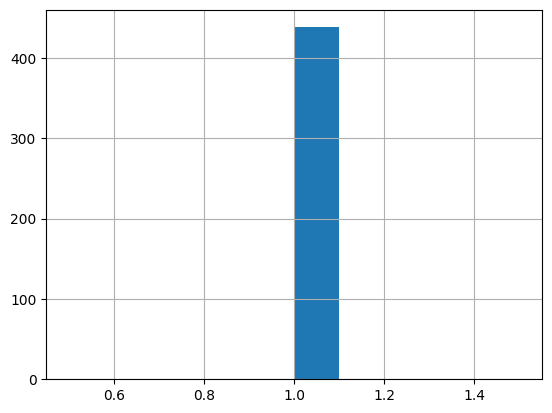

In [60]:
Hitter_Projections_df['FG ID'].value_counts().hist()

In [61]:
rest_of_roster_SP_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['Ottoneu Positions'] == 'SP']
full_roster_SP_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['Ottoneu Positions'] == 'SP']
rest_of_roster_RP_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['Ottoneu Positions'] == 'RP']
full_roster_RP_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['Ottoneu Positions'] == 'RP']
rest_of_roster_P_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['Ottoneu Positions'] == 'P']
full_roster_P_df = Pitching_Average_Stats_df[Pitching_Average_Stats_df['Ottoneu Positions'] == 'P']

In [62]:
rest_of_roster_SP_df['rest_of_roster_count'] = (Replacement_Level['SP']/Num_teams)-1.
full_roster_SP_df['full_roster_count'] = (Replacement_Level['SP']/Num_teams)
rest_of_roster_RP_df['rest_of_roster_count'] = (Replacement_Level['RP']/Num_teams)-1.
full_roster_RP_df['full_roster_count'] = (Replacement_Level['RP']/Num_teams)
rest_of_roster_P_df['rest_of_roster_count'] = (Replacement_Level['P']/Num_teams)-1.
full_roster_P_df['full_roster_count'] = (Replacement_Level['P']/Num_teams)

In [63]:
rest_of_roster_SP_df['rest_of_roster'] = rest_of_roster_SP_df['rest_of_roster_count']*rest_of_roster_SP_df['mean']
full_roster_SP_df['full_roster'] = full_roster_SP_df['full_roster_count']*full_roster_SP_df['mean']
rest_of_roster_RP_df['rest_of_roster'] = rest_of_roster_RP_df['rest_of_roster_count']*rest_of_roster_RP_df['mean']
full_roster_RP_df['full_roster'] = full_roster_RP_df['full_roster_count']*full_roster_RP_df['mean']
rest_of_roster_P_df['rest_of_roster'] = rest_of_roster_P_df['rest_of_roster_count']*rest_of_roster_P_df['mean']
full_roster_P_df['full_roster'] = full_roster_P_df['full_roster_count']*full_roster_P_df['mean']

In [64]:
rest_of_roster_SP_stats = rest_of_roster_SP_df.pivot_table('rest_of_roster','Ottoneu Positions','Stat')
full_roster_SP_stats = full_roster_SP_df.pivot_table('full_roster','Ottoneu Positions','Stat')
rest_of_roster_RP_stats = rest_of_roster_RP_df.pivot_table('rest_of_roster','Ottoneu Positions','Stat')
full_roster_RP_stats = full_roster_RP_df.pivot_table('full_roster','Ottoneu Positions','Stat')
rest_of_roster_P_stats = rest_of_roster_P_df.pivot_table('rest_of_roster','Ottoneu Positions','Stat')
full_roster_P_stats = full_roster_P_df.pivot_table('full_roster','Ottoneu Positions','Stat')

In [65]:
Pitcher_Projections_df['Ottoneu Positions'].value_counts().reset_index()

,Ottoneu Positions,count
0,RP,247
1,SP,158
2,SP/RP,74
3,Util/SP,1


<Axes: xlabel='IP', ylabel='Count'>

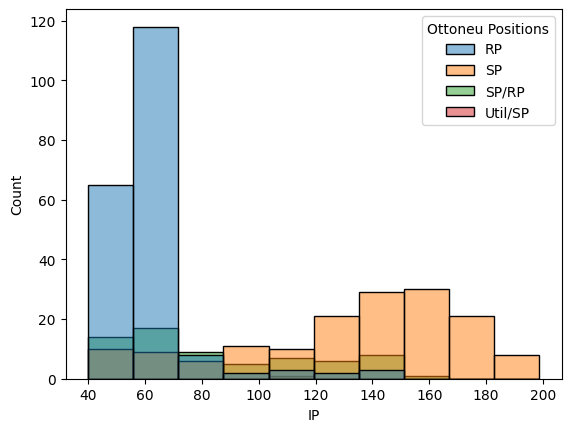

In [66]:
import seaborn as sns
sns.histplot(Pitcher_Projections_df[Pitcher_Projections_df['WAR']>0.05],x='IP',hue='Ottoneu Positions')

In [67]:
League_Avg_HR9 = HR9(
            full_roster_P_stats['HR'].values[0],
            full_roster_P_stats['IP'].values[0])

League_Avg_SP_HR9 = HR9(
            full_roster_SP_stats['HR'].values[0],
            full_roster_SP_stats['IP'].values[0])

League_Avg_RP_HR9 = HR9(
            full_roster_RP_stats['HR'].values[0],
            full_roster_RP_stats['IP'].values[0])

League_Avg_ERA = ERA(
            full_roster_P_stats['ER'].values[0],
            full_roster_P_stats['IP'].values[0])

League_Avg_SP_ERA = ERA(
            full_roster_SP_stats['ER'].values[0],
            full_roster_SP_stats['IP'].values[0])

League_Avg_RP_ERA = ERA(
            full_roster_RP_stats['ER'].values[0],
            full_roster_RP_stats['IP'].values[0])

League_Avg_WHIP = WHIP(
            full_roster_P_stats['BB'].values[0],
            full_roster_P_stats['H'].values[0],
            full_roster_P_stats['IP'].values[0]
)

League_Avg_SP_WHIP = WHIP(
            full_roster_SP_stats['BB'].values[0],
            full_roster_SP_stats['H'].values[0],
            full_roster_SP_stats['IP'].values[0]
)

League_Avg_RP_WHIP = WHIP(
            full_roster_RP_stats['BB'].values[0],
            full_roster_RP_stats['H'].values[0],
            full_roster_RP_stats['IP'].values[0]
)

# P League Average

In [68]:
print('HR9', League_Avg_HR9)
print('SP HR9', League_Avg_SP_HR9)
print('RP HR9', League_Avg_RP_HR9)
print('ERA', League_Avg_ERA)
print('SP ERA', League_Avg_SP_ERA)
print('RP ERA', League_Avg_RP_ERA)
print('WHIP', League_Avg_WHIP)
print('SP WHIP', League_Avg_SP_WHIP)
print('RP WHIP', League_Avg_RP_WHIP)

HR9 1.1481171545393833
SP HR9 1.1668968467388832
RP HR9 1.0767804303445536
ERA 3.969910081675275
SP ERA 4.005849442528916
RP ERA 3.8367710345388537
WHIP 1.2505015579086647
SP WHIP 1.2512789126112875
RP WHIP 1.2487017697076916


In [69]:
Pitcher_Projections_df[Pitcher_Projections_df['Pos Place']<(Replacement_Level['P'])]

,FG ID,Team,W,L,QS,G,GS,SV,HLD,IP,...,ADP,POS,Ottoneu ID,Ottoneu Positions,Name,HR9,ERA,WHIP,Pos Place,SO_SGP_raw
3,10233,BOS,4.411340,3.169422,0.000000,58.36838,0.00000,29.24422,2.260412,58.20950,...,64.040001,['RP'],5644,RP,Aroldis Chapman,0.776143,2.932553,1.139465,140.0,1.704373
4,10310,PHI,10.372512,6.042328,14.168960,22.88546,22.88546,0.00000,0.000000,141.50760,...,113.110001,['SP'],15962,SP,Zack Wheeler,1.062948,3.239469,1.087416,18.0,3.475511
7,10603,ATL,11.471640,6.560476,15.567720,26.54956,26.54956,0.00000,0.000000,158.97600,...,38.900002,['SP'],14393,SP,Chris Sale,0.973111,3.106430,1.091478,6.0,4.101721
8,10954,TEX,10.484660,7.292720,14.081360,27.25568,27.25568,0.00000,0.000000,162.71540,...,49.639999,['SP'],14294,SP,Jacob DeGrom,1.203006,3.415380,1.069513,15.0,3.800796
10,11156,ARI,9.946080,8.782792,13.531920,27.84218,27.84218,0.00000,0.000000,165.89840,...,275.709991,['SP'],17763,SP,Merrill Kelly,1.176901,4.180765,1.270076,64.0,3.113108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,8700,DET,7.689786,8.240772,10.012482,24.06896,24.06896,0.00000,0.000000,133.45320,...,701.369995,['SP'],15261,SP,Justin Verlander,1.353147,4.457786,1.301761,130.0,2.361939
872,9132,TEX,10.875920,8.317332,14.618660,26.56166,26.56166,0.00000,0.102650,161.65440,...,136.380005,['SP'],9335,SP,Nathan Eovaldi,1.049156,3.666286,1.151588,22.0,3.275312
873,9803,WSN,6.705054,9.781942,9.669728,25.85780,25.85780,0.00000,0.000000,142.35120,...,999.000000,['SP'],6106,SP,Miles Mikolas,1.495252,4.932135,1.324042,161.0,1.982885
1778,sa3020707,MIA,5.266152,5.488764,7.380720,16.05180,15.81972,0.00000,0.111386,85.34184,...,999.000000,['SP'],42741,SP,Robby Snelling,1.047330,4.109596,1.332314,143.0,1.605578


<Axes: >

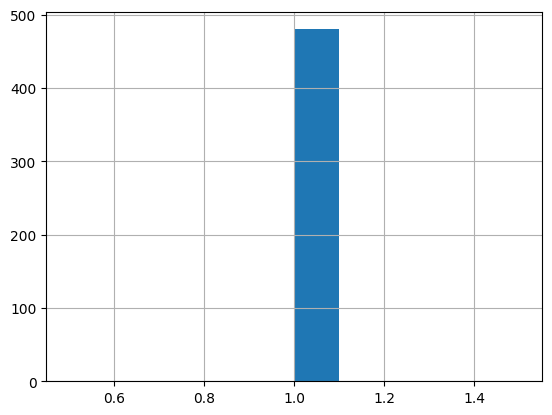

In [70]:
Pitcher_Projections_df['Pos Place'].value_counts().hist()

<Axes: xlabel='Pos Place', ylabel='Pos Place'>

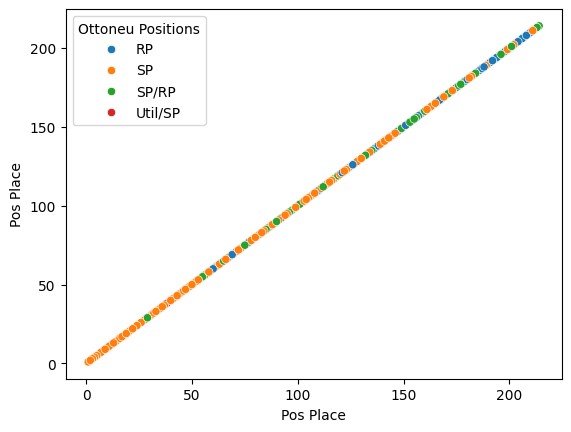

In [71]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['Pos Place']<Replacement_Level['P']],x='Pos Place',y='Pos Place',hue='Ottoneu Positions')

<Axes: xlabel='ERA', ylabel='Count'>

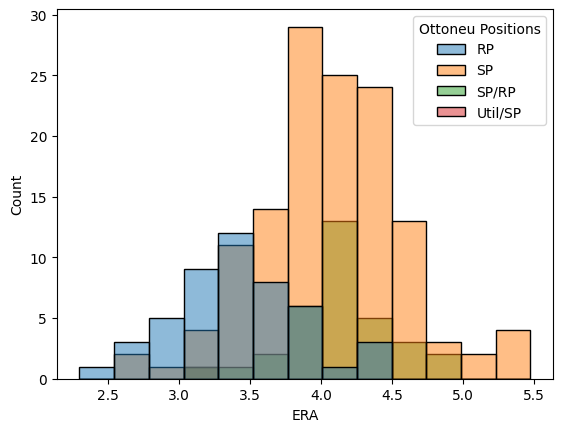

In [72]:
sns.histplot(Pitcher_Projections_df[Pitcher_Projections_df['Pos Place']<Replacement_Level['P']],x='ERA',hue='Ottoneu Positions')

<Axes: xlabel='IP', ylabel='Count'>

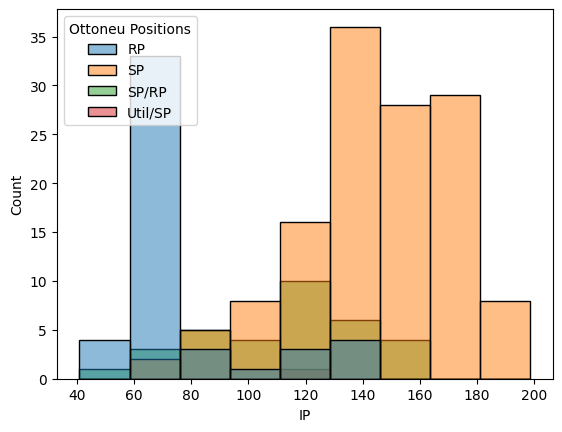

In [73]:
sns.histplot(Pitcher_Projections_df[Pitcher_Projections_df['Pos Place']<Replacement_Level['P']],x='IP',hue='Ottoneu Positions')

In [74]:
Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))

0       False
1       False
3       False
4        True
7        True
        ...  
1807     True
2279     True
2295     True
2698     True
2766     True
Name: Ottoneu Positions, Length: 480, dtype: bool

In [75]:
Pitcher_Projections_df['HR9_SGP_raw'] = (
    HR9(
        (Pitcher_Projections_df['HR'] \
         + np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
            rest_of_roster_SP_stats['HR'].values[0],
            rest_of_roster_RP_stats['HR'].values[0]
            )
        ),
        (Pitcher_Projections_df['IP'] \
         + np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
            rest_of_roster_SP_stats['IP'].values[0],
            rest_of_roster_RP_stats['IP'].values[0]
            )
        )
        )
    - np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
        League_Avg_SP_HR9,
        League_Avg_RP_HR9
    )
) / SGP_Denom['HR9']

In [76]:
Pitcher_Projections_df['ERA_SGP_raw'] = (
    ERA(
        (Pitcher_Projections_df['ER'] \
         + np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
            rest_of_roster_SP_stats['ER'].values[0],
            rest_of_roster_RP_stats['ER'].values[0]
            )
        ),
        (Pitcher_Projections_df['IP'] \
         + np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
            rest_of_roster_SP_stats['IP'].values[0],
            rest_of_roster_RP_stats['IP'].values[0]
            )
        )
        )
    - np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
        League_Avg_SP_ERA,
        League_Avg_RP_ERA
    )
) / SGP_Denom['ERA']

In [77]:
Pitcher_Projections_df['WHIP_SGP_raw'] = (
    WHIP(
        (Pitcher_Projections_df['BB'] \
         + np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
            rest_of_roster_SP_stats['BB'].values[0],
            rest_of_roster_RP_stats['BB'].values[0]
            )
        ),
        (Pitcher_Projections_df['H'] \
         + np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
            rest_of_roster_SP_stats['H'].values[0],
            rest_of_roster_RP_stats['H'].values[0]
            )
        ),
        (Pitcher_Projections_df['IP'] \
         + np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
            rest_of_roster_SP_stats['IP'].values[0],
            rest_of_roster_RP_stats['IP'].values[0]
            )
        )
        )
    - np.where(
            (Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : "SP" in x.strip('[]').split('/'))),
        League_Avg_SP_WHIP,
        League_Avg_RP_WHIP
    )
) / SGP_Denom['WHIP']

In [78]:
Pitcher_Projections_df['TOTAL_SGP_raw'] = Pitcher_Projections_df[[f'{col}_SGP_raw' for col in Scoring_Categories_Pitching]].sum(axis=1)

In [79]:
Pitcher_Projections_df.sort_values('TOTAL_SGP_raw',ascending=False).head(10)

,FG ID,Team,W,L,QS,G,GS,SV,HLD,IP,...,Name,HR9,ERA,WHIP,Pos Place,SO_SGP_raw,HR9_SGP_raw,ERA_SGP_raw,WHIP_SGP_raw,TOTAL_SGP_raw
448,22267,DET,14.552640,6.756664,20.096780,30.47210,30.472100,0.00000,0.000000,194.13400,...,Tarik Skubal,0.863428,2.640335,0.976146,1.0,4.966377,1.231127,1.612600,1.665243,9.475347
838,33677,PIT,12.848780,7.489942,19.305880,30.73478,30.734780,0.00000,0.000000,187.40360,...,Paul Skenes,0.766527,2.745258,1.045935,2.0,4.731310,1.573687,1.442358,1.204165,8.951520
643,27463,BOS,14.022020,8.010488,18.799900,30.40406,30.404060,0.00000,0.000000,189.91000,...,Garrett Crochet,0.937470,2.981706,1.072625,3.0,4.916763,0.912593,1.185867,1.060214,8.075437
808,31757,SDP,3.883400,2.475378,0.031216,62.14320,0.042689,33.05816,1.794878,64.99554,...,Mason Miller,0.806522,2.301331,0.980349,92.0,2.095321,1.366430,2.259869,2.024241,7.745861
373,20778,PHI,13.223820,7.705976,18.364020,30.40874,30.408740,0.00000,0.000000,193.48780,...,Cristopher Sanchez,0.785991,3.159332,1.143912,4.0,4.039052,1.540674,0.996715,0.647907,7.224347
203,17995,SFG,13.160560,9.328674,18.206660,30.82772,30.827720,0.00000,0.106613,198.65560,...,Logan Webb,0.729400,3.278294,1.172056,5.0,4.008410,1.811740,0.877060,0.489465,7.186675
378,21029,PHI,5.372436,3.510774,0.000000,66.69334,0.000000,31.41608,2.361198,67.37692,...,Jhoan Duran,0.603322,2.699744,1.102788,109.0,1.669453,2.469617,1.726476,1.135509,7.001055
697,27867,CLE,4.928648,3.396720,0.000000,67.48336,0.000000,30.89556,3.050160,68.64706,...,Cade Smith,0.749179,2.786144,1.056325,110.0,1.852865,1.736579,1.621211,1.521421,6.732076
7,10603,ATL,11.471640,6.560476,15.567720,26.54956,26.549560,0.00000,0.000000,158.97600,...,Chris Sale,0.973111,3.106430,1.091478,6.0,4.101721,0.656328,0.886756,0.807469,6.452274
779,30279,SEA,13.618040,8.684844,17.637300,30.37472,30.374720,0.00000,0.000000,188.86760,...,Bryan Woo,1.147730,3.301258,1.042200,13.0,4.088763,0.075866,0.811837,1.234662,6.211127


<Axes: >

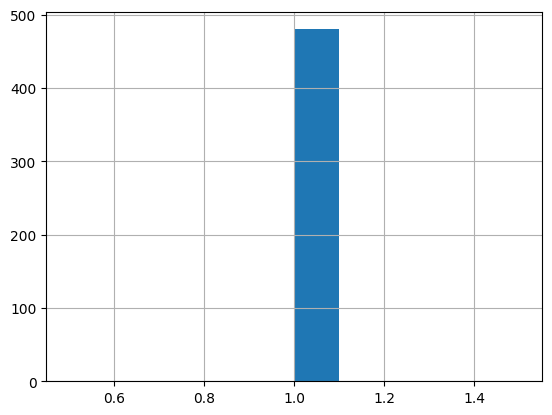

In [80]:
Pitcher_Projections_df['FG ID'].value_counts().hist()

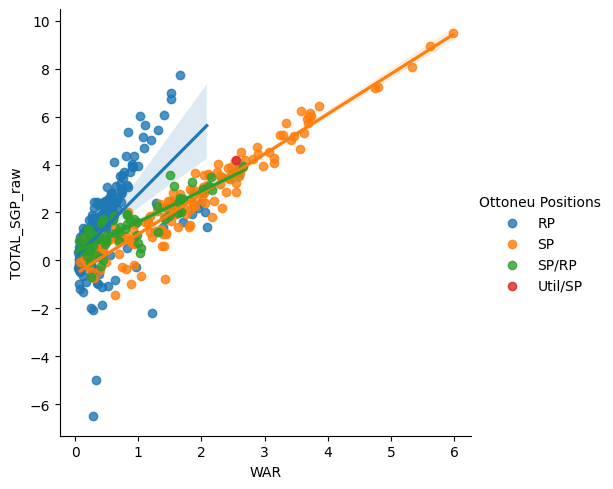

In [81]:
sns.lmplot(Pitcher_Projections_df[Pitcher_Projections_df['WAR']>0.05],x='WAR',y='TOTAL_SGP_raw',hue='Ottoneu Positions')

# Replacement Level SGP

In [82]:
Hitting_Replacement_pivot_df = Hitting_Replacement_Stats_df.pivot_table('mean','Ottoneu Positions','Stat').reset_index()

In [83]:
Hitting_Replacement_pivot_df

Stat,Ottoneu Positions,1B,2B,3B,AB,ADP,BB,G,H,HBP,HR,PA,R,RBI,SF,WAR
0,1B,72.469636,23.520284,0.948114,466.54504,291.298004,49.678476,126.511120,115.185320,5.732051,18.247174,526.47104,62.626184,63.821176,3.703045,1.588788
1,2B,93.936628,26.287784,1.725621,513.77624,319.708008,41.396944,133.965920,135.024520,5.801014,13.074468,567.24844,66.349680,61.283208,4.138422,1.762746
2,3B,75.273096,22.299448,1.543384,473.98772,554.745996,47.911060,128.713880,115.439796,6.269968,16.163888,533.74376,62.829712,59.643072,3.712833,1.854125
3,C,56.137340,15.652012,0.630466,357.82580,501.323993,35.477940,102.200936,85.269852,4.305443,13.010048,401.58396,45.133724,45.876724,2.755990,1.757226
4,OF,61.283196,19.335072,2.267352,412.31308,529.867999,41.058776,112.000764,94.930820,4.604060,12.125236,463.27568,53.901396,47.192224,3.211620,1.004465
5,SS,66.473600,21.402060,2.215690,417.91068,704.044006,32.265252,112.336380,100.439604,5.155890,10.188203,460.44680,50.977896,47.463764,3.527378,1.230188
6,Util,62.054632,18.789204,1.732670,398.98824,602.882001,36.384912,109.145860,96.123664,4.733547,13.787137,444.99840,51.590460,51.062920,3.191001,0.938685


In [84]:
Hitting_Replacement_SGP_df = pd.DataFrame()
for pos in Hitting_Pos:
    this_pos_repl_df = Hitting_Replacement_pivot_df[Hitting_Replacement_pivot_df['Ottoneu Positions'] == pos]
    This_pos_dict = {
            'Ottoneu Positions':pos,
        }
    quick_running_sum = 0.
    for stat in Count_Scoring_Categories_Batting:
        Repl_mean = this_pos_repl_df[f'{stat}'].values[0]

        This_pos_dict[f'{stat}_SGP_raw'] = Repl_mean/SGP_Denom[stat]
        quick_running_sum += This_pos_dict[f'{stat}_SGP_raw']

    This_pos_dict['OBP'] = OBP(
        (this_pos_repl_df['H'].values[0]),
        (this_pos_repl_df['BB'].values[0]),
        (this_pos_repl_df['HBP'].values[0]),
        (this_pos_repl_df['SF'].values[0]),
        (this_pos_repl_df['AB'].values[0])
    )

    This_pos_dict['OBP_SGP_raw'] = (OBP(
        (this_pos_repl_df['H'].values[0]+rest_of_roster_stats['H'].values[0]),
        (this_pos_repl_df['BB'].values[0]+rest_of_roster_stats['BB'].values[0]),
        (this_pos_repl_df['HBP'].values[0]+rest_of_roster_stats['HBP'].values[0]),
        (this_pos_repl_df['SF'].values[0]+rest_of_roster_stats['SF'].values[0]),
        (this_pos_repl_df['AB'].values[0]+rest_of_roster_stats['AB'].values[0])) \
    - full_roster_OBP) / SGP_Denom['OBP']

    quick_running_sum += This_pos_dict['OBP_SGP_raw']
    
    repl_level_TB = TB(
    this_pos_repl_df['1B'].values[0],
    this_pos_repl_df['2B'].values[0],
    this_pos_repl_df['3B'].values[0],
    this_pos_repl_df['HR'].values[0])

    This_pos_dict['SLG'] = SLG(
        (repl_level_TB),
        (this_pos_repl_df['AB'].values[0])
    )

    This_pos_dict['SLG_SGP_raw'] = (
    SLG(
        (repl_level_TB+rest_of_roster_TB),
        (this_pos_repl_df['AB'].values[0]+rest_of_roster_stats['AB'].values[0])) \
    -  full_roster_SLG) / SGP_Denom['SLG']

    quick_running_sum += This_pos_dict['SLG_SGP_raw']

    This_pos_dict['TOTAL_SGP_raw'] = quick_running_sum

    Hitting_Replacement_SGP_df = pd.concat([
        Hitting_Replacement_SGP_df,
        pd.DataFrame([This_pos_dict])
    ])

In [85]:
Hitting_Replacement_SGP_df

,Ottoneu Positions,R_SGP_raw,HR_SGP_raw,OBP,OBP_SGP_raw,SLG,SLG_SGP_raw,TOTAL_SGP_raw
0,C,1.785175,1.130482,0.312348,-0.209549,0.395089,-0.218273,2.487836
0,1B,2.477055,1.585552,0.324537,-0.026758,0.418702,-0.057531,3.978317
0,2B,2.624330,1.136080,0.322453,-0.073531,0.397035,-0.287981,3.398899
0,SS,2.016330,0.885284,0.300442,-0.449099,0.374907,-0.425464,2.027051
0,3B,2.485105,1.404529,0.318907,-0.141526,0.399077,-0.247165,3.500943
0,OF,2.131963,1.053598,0.304851,-0.373022,0.376550,-0.406183,2.406356
0,Util,2.040559,1.198006,0.309594,-0.278129,0.400963,-0.194350,2.766086


In [86]:
Hitting_Replacement_SGP_df = Hitting_Replacement_SGP_df.set_index('Ottoneu Positions')

In [87]:
pd.DataFrame(Hitter_Projections_df['Ottoneu Positions'].apply(lambda x : (min(Hitting_Replacement_SGP_df[Hitting_Replacement_SGP_df.index.isin(x.split('/'))]['R_SGP_raw']),Hitting_Replacement_SGP_df[Hitting_Replacement_SGP_df.index.isin(x.split('/'))]['TOTAL_SGP_raw'].idxmin())).to_list(),index=Hitter_Projections_df.index)

,0,1
1,2.131963,OF
2,2.131963,OF
3,2.040559,Util
4,2.131963,OF
6,1.785175,C
...,...,...
2042,2.131963,OF
2148,2.131963,OF
2208,2.040559,Util
2209,2.485105,3B


In [88]:
for stat in Scoring_Categories_Batting:
    Hitter_Projections_df[[f'{stat}_SGP_repl','Repl_Pos']] = pd.DataFrame(Hitter_Projections_df['Ottoneu Positions'].apply(lambda x : (min(Hitting_Replacement_SGP_df[Hitting_Replacement_SGP_df.index.isin(x.split('/'))][f'{stat}_SGP_raw']),Hitting_Replacement_SGP_df[Hitting_Replacement_SGP_df.index.isin(x.split('/'))]['TOTAL_SGP_raw'].idxmin())).to_list(),index=Hitter_Projections_df.index)
    Hitter_Projections_df[f'{stat}_SGP_norm'] = Hitter_Projections_df[f'{stat}_SGP_raw'] - Hitter_Projections_df[f'{stat}_SGP_repl']

In [89]:
Hitter_Projections_df.head()

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,TOTAL_SGP_raw,R_SGP_repl,Repl_Pos,R_SGP_norm,HR_SGP_repl,HR_SGP_norm,OBP_SGP_repl,OBP_SGP_norm,SLG_SGP_repl,SLG_SGP_norm
1,10155,LAA,122.63920,525.3260,444.6746,106.01270,60.76846,17.718100,1.799282,25.726840,...,5.756668,2.131963,OF,0.627707,1.053598,1.181885,-0.373022,0.816481,-0.406183,0.724239
2,10243,NYY,35.85476,144.5400,132.6196,31.55082,19.18724,6.811464,0.400766,5.551346,...,0.934886,2.131963,OF,-1.475464,1.053598,-0.571225,-0.373022,0.171468,-0.406183,0.403751
3,10324,PIT,123.24320,522.2472,453.2730,110.13880,69.28562,19.842960,0.108619,20.901560,...,4.416749,2.040559,Util,0.367974,1.198006,0.618194,-0.278129,0.462717,-0.194350,0.201778
4,10472,LAD,47.12238,186.0596,169.1838,37.58262,24.30588,8.091872,0.086417,5.498438,...,0.744909,2.131963,OF,-1.343668,1.053598,-0.575823,-0.373022,0.043237,-0.406183,0.214807
6,11442,MIL,41.04282,156.9806,139.6408,30.45850,18.43844,5.254154,0.064672,6.701256,...,1.024736,1.785175,C,-1.091471,1.130482,-0.548190,-0.209549,0.029220,-0.218273,0.147343


In [90]:
Hitter_Projections_df.groupby('Repl_Pos')['Ottoneu Positions'].value_counts()

Repl_Pos  Ottoneu Positions
1B        1B                    36
2B        2B                    16
          2B/3B                 13
          1B/2B                  4
          1B/2B/3B               2
3B        3B                    24
          1B/3B                  4
C         C                     59
          C/1B                   5
OF        OF                   152
          1B/OF                 13
          2B/OF                 10
          2B/3B/OF               7
          3B/OF                  3
          1B/2B/OF               2
          1B/2B/3B/OF            1
          1B/3B/OF               1
          1B/2B/3B/OF/RP         1
          1B/OF/RP               1
SS        SS                    28
          2B/SS                 17
          2B/SS/3B               9
          2B/SS/3B/OF            6
          1B/2B/SS/3B            5
          2B/SS/OF               4
          SS/3B                  2
          SS/3B/OF               2
          1B/SS/3B/OF      

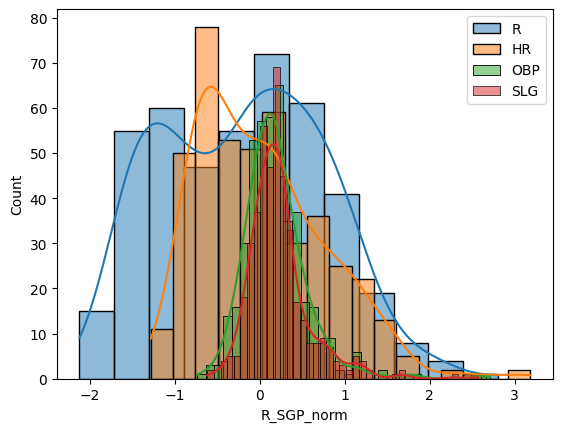

In [91]:
for stat in Scoring_Categories_Batting:
    sns.histplot(Hitter_Projections_df,x=f'{stat}_SGP_norm',label=stat,kde=True)
    #Hitter_Projections_df[f'{stat}_SGP_norm'].hist(label=stat)
plt.legend()

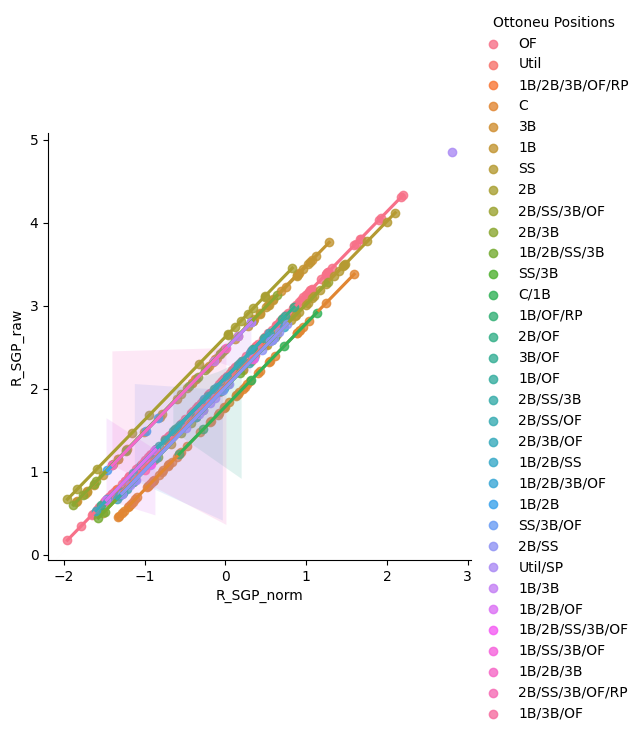

In [92]:
sns.lmplot(Hitter_Projections_df[Hitter_Projections_df['WAR']>0.05],x='R_SGP_norm',y='R_SGP_raw',hue='Ottoneu Positions')

In [93]:
Pitching_Replacement_pivot_df = Pitching_Replacement_Stats_df.pivot_table('mean','Ottoneu Positions','Stat').reset_index()

In [94]:
Pitching_Replacement_pivot_df

Stat,Ottoneu Positions,ADP,BB,ER,G,GS,H,HBP,HLD,HR,IP,L,QS,R,SO,SV,TBF,W,WAR
0,P,895.026001,22.144908,28.665360,47.120432,3.924294,60.470868,3.019107,8.851830,7.682050,66.263828,3.401103,2.066167,31.217132,64.884048,1.299995,279.23156,3.746537,0.612395
1,RP,223.788002,24.290684,24.118096,61.722080,0.000000,51.010480,2.864965,5.854661,6.919837,62.778776,3.374722,0.000000,26.288360,71.129408,23.044998,261.29036,3.981660,0.733464
2,SP,771.854004,36.816320,48.052764,34.074948,14.520852,94.896548,5.108533,0.955152,12.672920,97.289084,5.386478,5.650156,52.380820,85.805776,0.604068,419.30708,4.974009,0.816315


In [95]:
Pitching_Replacement_SGP_df = pd.DataFrame()
for pos in Pitching_Pos:
    this_pos_repl_df = Pitching_Replacement_pivot_df[Pitching_Replacement_pivot_df['Ottoneu Positions'] == pos]
    This_pos_dict = {
            'Ottoneu Positions':pos,
        }
    quick_running_sum = 0.
    for stat in Count_Scoring_Categories_Pitching:
        Repl_mean = this_pos_repl_df[f'{stat}'].values[0]

        This_pos_dict[f'{stat}_SGP_raw'] = Repl_mean/SGP_Denom[stat]
        quick_running_sum += This_pos_dict[f'{stat}_SGP_raw']

    This_pos_dict['HR9'] = HR9(
        this_pos_repl_df['HR'].values[0],
        this_pos_repl_df['IP'].values[0]
    )

    This_pos_dict['HR9_SGP_raw'] = (
    HR9(
        np.where(
            pos == 'SP',
            (this_pos_repl_df['HR'].values[0]+rest_of_roster_SP_stats['HR'].values[0]),
            (this_pos_repl_df['HR'].values[0]+rest_of_roster_RP_stats['HR'].values[0])
        ),
        np.where(
            pos == 'SP',
            (this_pos_repl_df['IP'].values[0]+rest_of_roster_SP_stats['IP'].values[0]),
            (this_pos_repl_df['IP'].values[0]+rest_of_roster_RP_stats['IP'].values[0])
        )) \
    - np.where(
        pos == 'SP',
        HR9(
            full_roster_SP_stats['HR'].values[0],
            full_roster_SP_stats['IP'].values[0]),
        HR9(
            full_roster_RP_stats['HR'].values[0],
            full_roster_RP_stats['IP'].values[0])     
    ) ) / SGP_Denom['HR9']

    quick_running_sum += This_pos_dict['HR9_SGP_raw']

    This_pos_dict['ERA'] = ERA(
        this_pos_repl_df['ER'].values[0],
        this_pos_repl_df['IP'].values[0]
    )

    This_pos_dict['ERA_SGP_raw'] = (
    ERA(
        np.where(
            pos == 'SP',
            (this_pos_repl_df['ER'].values[0]+rest_of_roster_SP_stats['ER'].values[0]),
            (this_pos_repl_df['ER'].values[0]+rest_of_roster_RP_stats['ER'].values[0])
        ),
        np.where(
            pos == 'SP',
            (this_pos_repl_df['IP'].values[0]+rest_of_roster_SP_stats['IP'].values[0]),
            (this_pos_repl_df['IP'].values[0]+rest_of_roster_RP_stats['IP'].values[0])
        )) \
    - np.where(
        pos == 'SP',
        ERA(
            full_roster_SP_stats['ER'].values[0],
            full_roster_SP_stats['IP'].values[0]),
        ERA(
            full_roster_RP_stats['ER'].values[0],
            full_roster_RP_stats['IP'].values[0])     
    ) ) / SGP_Denom['ERA']

    quick_running_sum += This_pos_dict['ERA_SGP_raw']


    This_pos_dict['WHIP'] = WHIP(
        this_pos_repl_df['BB'].values[0],
        this_pos_repl_df['H'].values[0],
        this_pos_repl_df['IP'].values[0]
    )

    This_pos_dict['WHIP_SGP_raw'] = (
    WHIP(
        np.where(
            pos == 'SP',
            (this_pos_repl_df['BB'].values[0]+rest_of_roster_SP_stats['BB'].values[0]),
            (this_pos_repl_df['BB'].values[0]+rest_of_roster_RP_stats['BB'].values[0])
        ),
        np.where(
            pos == 'SP',
            (this_pos_repl_df['H'].values[0]+rest_of_roster_SP_stats['H'].values[0]),
            (this_pos_repl_df['H'].values[0]+rest_of_roster_RP_stats['H'].values[0])
        ),
        np.where(
            pos == 'SP',
            (this_pos_repl_df['IP'].values[0]+rest_of_roster_SP_stats['IP'].values[0]),
            (this_pos_repl_df['IP'].values[0]+rest_of_roster_RP_stats['IP'].values[0])
        )) \
    - np.where(
        pos == 'SP',
        WHIP(
            full_roster_SP_stats['BB'].values[0],
            full_roster_SP_stats['H'].values[0],
            full_roster_SP_stats['IP'].values[0]),
        WHIP(
            full_roster_RP_stats['BB'].values[0],
            full_roster_RP_stats['H'].values[0],
            full_roster_RP_stats['IP'].values[0])     
    ) ) / SGP_Denom['WHIP']

    quick_running_sum += This_pos_dict['WHIP_SGP_raw']

    This_pos_dict['TOTAL_SGP_raw'] = quick_running_sum

    Pitching_Replacement_SGP_df = pd.concat([
        Pitching_Replacement_SGP_df,
        pd.DataFrame([This_pos_dict])
    ])

In [96]:
Pitching_Replacement_SGP_df

,Ottoneu Positions,SO_SGP_raw,HR9,HR9_SGP_raw,ERA,ERA_SGP_raw,WHIP,WHIP_SGP_raw,TOTAL_SGP_raw
0,SP,1.805573,1.172344,-0.011690,4.445256,-0.274505,1.353830,-0.328343,1.191035
0,RP,1.496745,0.992032,0.415742,3.457584,0.541485,1.199468,0.360327,2.814299
0,P,1.365327,1.043381,0.171720,3.893349,-0.084680,1.246770,0.014815,1.467182


In [97]:
Pitching_Replacement_SGP_df = Pitching_Replacement_SGP_df.set_index('Ottoneu Positions')

In [98]:
Pitcher_Projections_df['Ottoneu Positions'].value_counts()

Ottoneu Positions
RP         247
SP         158
SP/RP       74
Util/SP      1
Name: count, dtype: int64

In [99]:
for stat in Scoring_Categories_Pitching:
    Pitcher_Projections_df[[f'{stat}_SGP_repl','Repl_Pos']] = pd.DataFrame(Pitcher_Projections_df['Ottoneu Positions'].apply(lambda x : (min(Pitching_Replacement_SGP_df[Pitching_Replacement_SGP_df.index.isin(x.split('/'))][f'{stat}_SGP_raw']),Pitching_Replacement_SGP_df[Pitching_Replacement_SGP_df.index.isin(x.split('/'))]['TOTAL_SGP_raw'].idxmin())).to_list(),index=Pitcher_Projections_df.index)
    Pitcher_Projections_df[f'{stat}_SGP_norm'] = Pitcher_Projections_df[f'{stat}_SGP_raw'] - Pitcher_Projections_df[f'{stat}_SGP_repl']

In [100]:
Pitcher_Projections_df['TOTAL_SGP'] = Pitcher_Projections_df[[f'{col}_SGP_norm' for col in Scoring_Categories_Pitching]].sum(axis=1)
Hitter_Projections_df['TOTAL_SGP'] = Hitter_Projections_df[[f'{col}_SGP_norm' for col in Scoring_Categories_Batting]].sum(axis=1)

In [101]:
Hitter_Projections_df.sort_values(['TOTAL_SGP'])

,FG ID,Team,G,PA,AB,H,1B,2B,3B,HR,...,R_SGP_repl,Repl_Pos,R_SGP_norm,HR_SGP_repl,HR_SGP_norm,OBP_SGP_repl,OBP_SGP_norm,SLG_SGP_repl,SLG_SGP_norm,TOTAL_SGP
139,17982,SDP,36.90146,149.5996,134.0292,33.52600,24.02274,6.312902,0.067537,3.522858,...,2.477055,1B,-1.847054,1.585552,-1.279440,-0.026758,-0.021228,-0.057531,-0.068615,-3.216336
443,25714,COL,35.53538,143.9652,129.7458,31.20602,20.35172,6.282746,0.096010,4.475554,...,2.477055,1B,-1.848170,1.585552,-1.196658,-0.026758,-0.075639,-0.057531,-0.026862,-3.147329
1968,sa3025257,COL,37.80224,153.7566,137.4412,32.20756,21.12230,6.138644,1.010410,4.336200,...,2.477055,1B,-1.808294,1.585552,-1.208767,-0.026758,-0.085452,-0.057531,-0.039435,-3.141948
44,13621,LAA,30.80444,127.3766,114.9822,23.97780,14.56624,5.360028,0.098161,3.553384,...,2.477055,3B,-1.980929,1.404529,-1.095765,-0.141526,-0.108011,-0.247165,0.056217,-3.128488
205,19566,CIN,41.35796,166.1554,145.4942,35.63214,24.71440,5.936386,0.174031,4.407300,...,2.477055,1B,-1.741851,1.585552,-1.202589,-0.026758,0.056784,-0.057531,-0.091048,-2.978704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,18401,ATL,146.62000,637.7970,540.8704,153.88340,95.87016,26.167480,1.995500,29.850500,...,2.131963,OF,1.925663,1.053598,1.540202,-0.373022,1.853072,-0.406183,1.289618,6.608555
444,25764,KCR,153.70480,667.9780,605.5596,179.11080,105.36520,37.272440,6.556240,29.917040,...,2.016330,SS,2.102643,0.885284,1.714298,-0.449099,1.127455,-0.425464,1.666548,6.610944
252,20123,NYM,156.43260,681.3134,549.3626,152.46020,86.94412,25.724100,1.403924,38.788260,...,2.131963,OF,2.201213,1.053598,2.316831,-0.373022,2.543493,-0.406183,1.702624,8.764161
217,19755,LAD,151.88260,667.6870,568.2966,162.18180,81.39348,27.914720,5.470212,47.803460,...,2.040559,Util,2.806087,1.198006,2.955781,-0.278129,1.774877,-0.194350,2.272643,9.809387


<Axes: xlabel='ADP', ylabel='TOTAL_SGP'>

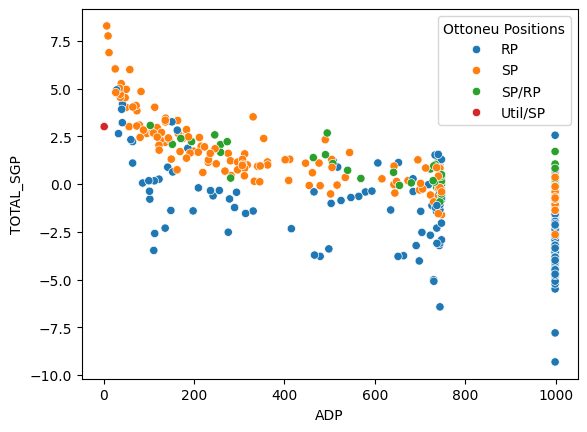

In [102]:
sns.scatterplot(Pitcher_Projections_df,y='TOTAL_SGP',x='ADP',hue='Ottoneu Positions')

In [103]:
Pitcher_Projections_df['TOTAL_SGP_Rank'] = Pitcher_Projections_df['TOTAL_SGP'].rank(ascending=False)
Hitter_Projections_df['TOTAL_SGP_Rank'] = Hitter_Projections_df['TOTAL_SGP'].rank(ascending=False)

<Axes: xlabel='TOTAL_SGP_Rank', ylabel='TOTAL_SGP'>

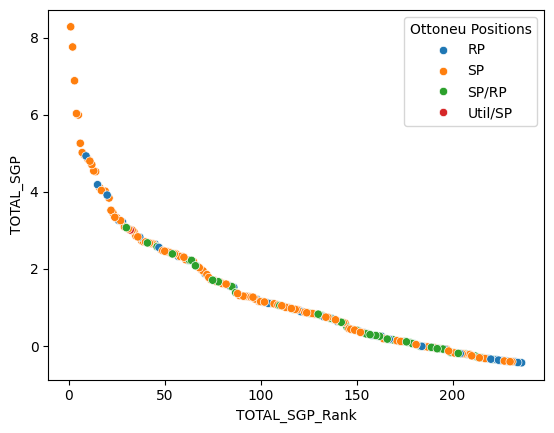

In [104]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['P']*1.1],x='TOTAL_SGP_Rank',y='TOTAL_SGP',hue='Ottoneu Positions')

<Axes: xlabel='TOTAL_SGP', ylabel='Count'>

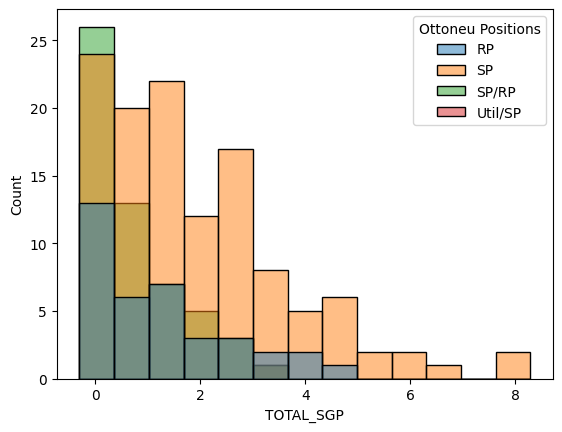

In [105]:
sns.histplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['P']],x='TOTAL_SGP',hue='Ottoneu Positions')

<Axes: xlabel='ADP', ylabel='TOTAL_SGP'>

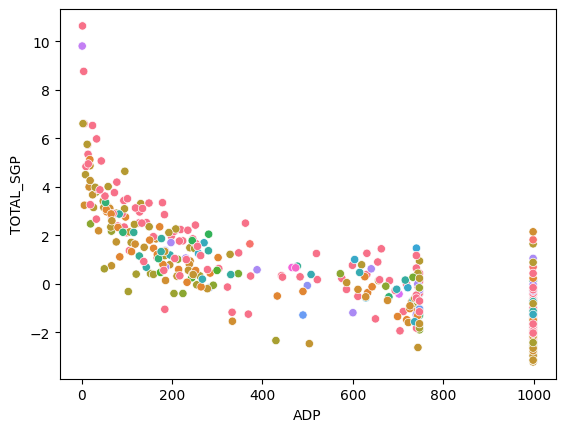

In [106]:
sns.scatterplot(Hitter_Projections_df,y='TOTAL_SGP',x='ADP',hue='Ottoneu Positions',legend=False)

<Axes: xlabel='TOTAL_SGP_Rank', ylabel='TOTAL_SGP'>

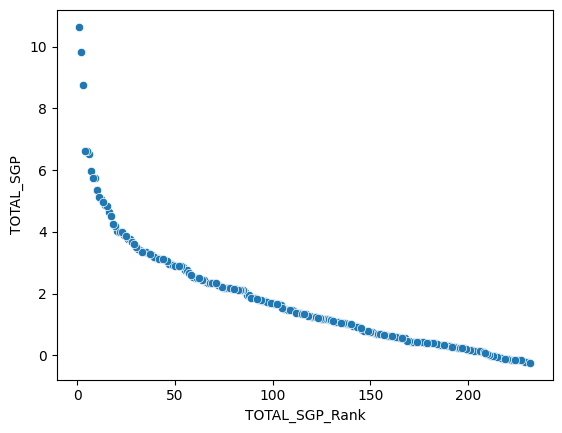

In [107]:
sns.scatterplot(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['Util']],x='TOTAL_SGP_Rank',y='TOTAL_SGP')

In [108]:
Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP'] > 0.]['TOTAL_SGP'].count()/Num_teams

np.float64(17.5)

In [109]:
Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['Util']]['TOTAL_SGP'].count()/Num_teams

np.float64(19.333333333333332)

In [110]:
Pitcher_Projections_df[(Pitcher_Projections_df['TOTAL_SGP'] > 0.)].groupby('Ottoneu Positions')['TOTAL_SGP'].count()/Num_teams

Ottoneu Positions
RP         2.583333
SP         8.916667
SP/RP      3.583333
Util/SP    0.083333
Name: TOTAL_SGP, dtype: float64

In [111]:
Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['P']].groupby('Ottoneu Positions')['TOTAL_SGP'].count()/Num_teams

Ottoneu Positions
RP          3.083333
SP         10.083333
SP/RP       4.583333
Util/SP     0.083333
Name: TOTAL_SGP, dtype: float64

<Axes: xlabel='TOTAL_SGP', ylabel='Count'>

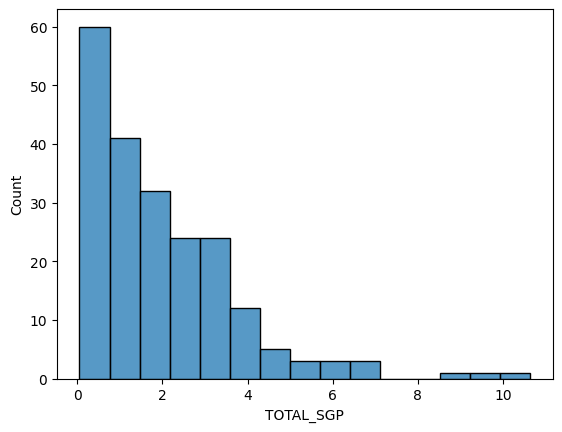

In [112]:
sns.histplot(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP'] > 0.],x='TOTAL_SGP')

<Axes: xlabel='TOTAL_SGP', ylabel='Count'>

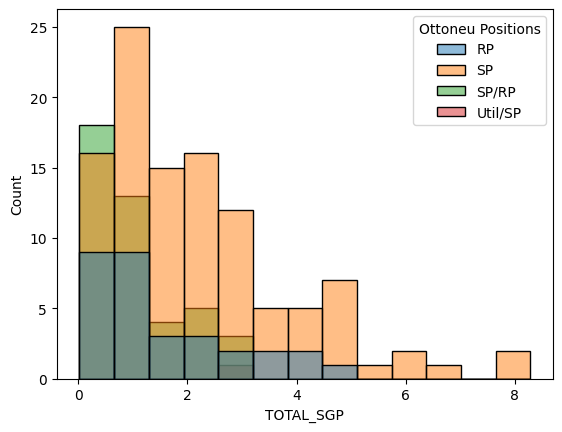

In [113]:
sns.histplot(Pitcher_Projections_df[(Pitcher_Projections_df['TOTAL_SGP'] > 0.)],x='TOTAL_SGP',hue='Ottoneu Positions')

In [114]:
# Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['Util']]['TOTAL_SGP'].sum()

In [115]:
Hitter_budget/12

212.0

In [116]:
Val_per_SGP_Hitter = Hitter_budget/(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] <= Replacement_Level['Util']]['TOTAL_SGP'].sum())

In [117]:
Val_per_SGP_Hitter

np.float64(6.1721573276726325)

In [118]:
Hitter_Projections_df['TOTAL_SGP_Val'] = Hitter_Projections_df['TOTAL_SGP']*Val_per_SGP_Hitter

In [119]:
Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] <= Replacement_Level['Util']]['TOTAL_SGP'].count()

np.int64(233)

In [120]:
Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Val'] >= 0.]['TOTAL_SGP'].count()

np.int64(210)

In [121]:
Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] <= Replacement_Level['Util']]['TOTAL_SGP_Val'].sum()/Num_teams

np.float64(212.0)

In [122]:
Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Val'] >= 0.]['TOTAL_SGP_Val'].sum()/Num_teams

np.float64(213.573616144576)

In [123]:
Hitter_Projections_df[(Hitter_Projections_df['TOTAL_SGP_Rank'] <= Replacement_Level['Util']+Replacement_window['Util']/2) & (Hitter_Projections_df['TOTAL_SGP_Rank'] >= Replacement_Level['Util']-Replacement_window['Util']/2)]['TOTAL_SGP_Val'].mean()

np.float64(-1.5549403604343213)

In [124]:
Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Val'] >= 0.].groupby(['Repl_Pos'])[['Ottoneu Positions']].count()

,Ottoneu Positions
Repl_Pos,
1B,19
2B,12
3B,14
C,25
OF,93
SS,43
Util,4


In [125]:
Replacement_Level

{'C': 24,
 '1B': 25,
 '2B': 27,
 'SS': 44,
 '3B': 19,
 'OF': 89,
 'Util': 233,
 'SP': 150,
 'RP': 65,
 'P': 215}

In [126]:
for stat in Scoring_Categories_Batting:
    Val_per_stat_SGP_Hitter = Hitter_budget/(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['Util']][f'{stat}_SGP_norm'].sum())
    Hitter_Projections_df[f'{stat}_SGP_Val'] = Hitter_Projections_df[f'{stat}_SGP_norm']*Val_per_stat_SGP_Hitter
    print(stat, Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Val'] >= 0.][f'{stat}_SGP_Val'].sum()/Num_teams)

R 218.707591489515
HR 214.75715894249313
OBP 210.03546281080375
SLG 206.7707136126428


<Axes: xlabel='TOTAL_SGP_Val', ylabel='Count'>

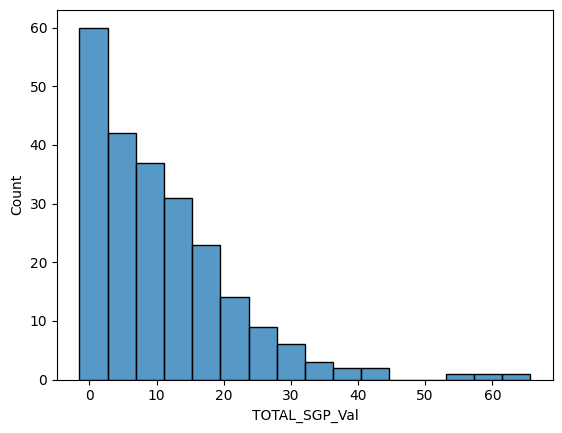

In [127]:
sns.histplot(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['Util']],x='TOTAL_SGP_Val')

In [128]:
print(f'Pct bias Hitting: {(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Val'] >= 0.]['TOTAL_SGP_Val'].sum() - Hitter_budget)/Hitter_budget*100:.2f}%')

Pct bias Hitting: 0.74%


<Axes: xlabel='TOTAL_SGP_Val', ylabel='TOTAL_SGP'>

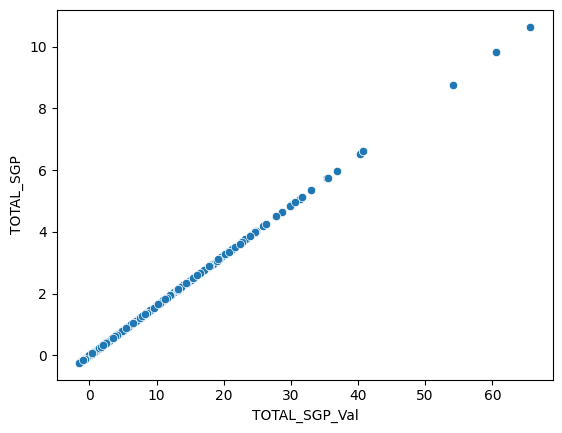

In [129]:
sns.scatterplot(Hitter_Projections_df[Hitter_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['Util']],x='TOTAL_SGP_Val',y='TOTAL_SGP')

In [130]:
# Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['P']]['TOTAL_SGP'].sum()

In [131]:
Val_per_SGP_Pitcher = Pitcher_budget/(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['Util']]['TOTAL_SGP'].sum())

In [132]:
Val_per_SGP_Pitcher

np.float64(7.105178687032989)

In [133]:
Pitcher_Projections_df['TOTAL_SGP_Val'] = Pitcher_Projections_df['TOTAL_SGP']*Val_per_SGP_Pitcher

In [134]:
Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['P']]['TOTAL_SGP'].count()

np.int64(214)

In [135]:
Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 0.]['TOTAL_SGP'].count()

np.int64(182)

In [136]:
Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 0.]['TOTAL_SGP_Val'].sum()/Num_teams

np.float64(194.3843924235041)

In [137]:
for stat in Scoring_Categories_Pitching:
    Val_per_stat_SGP_Pitcher = Pitcher_budget/(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Rank'] < Replacement_Level['P']][f'{stat}_SGP_norm'].sum())
    Pitcher_Projections_df[f'{stat}_SGP_Val'] = Pitcher_Projections_df[f'{stat}_SGP_norm']*Val_per_stat_SGP_Pitcher
    print(stat, Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 0.][f'{stat}_SGP_Val'].sum()/Num_teams)

SO 189.55547939214193
HR9 213.38757659020416
ERA 189.04552951957172
WHIP 182.14244632032774


In [138]:
print(f'Pct bias Pitching: {(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 0.]['TOTAL_SGP_Val'].sum() - Pitcher_budget)/Pitcher_budget*100:.2f}%')

Pct bias Pitching: 3.40%


<Axes: xlabel='TOTAL_SGP_Val', ylabel='TOTAL_SGP'>

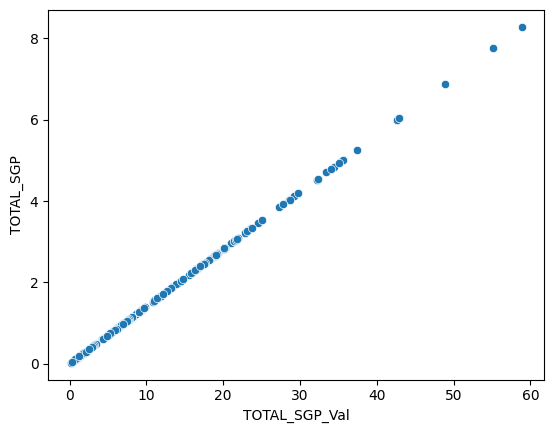

In [139]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 0.],x='TOTAL_SGP_Val',y='TOTAL_SGP')

In [140]:
Pitcher_Projections_df[Player_id_cols+['IP','SO','HR9','ERA','WHIP','SO_SGP_Val','HR9_SGP_Val','ERA_SGP_Val','WHIP_SGP_Val','TOTAL_SGP','TOTAL_SGP_Val']].sort_values('TOTAL_SGP_Val',ascending=False)

,FG ID,Ottoneu ID,Name,Ottoneu Positions,Team,IP,SO,HR9,ERA,WHIP,SO_SGP_Val,HR9_SGP_Val,ERA_SGP_Val,WHIP_SGP_Val,TOTAL_SGP,TOTAL_SGP_Val
448,22267,35204,Tarik Skubal,SP,DET,194.13400,236.01580,0.863428,2.640335,0.976146,45.501787,80.638726,64.482506,67.628156,8.284312,58.861518
838,33677,43894,Paul Skenes,SP,PIT,187.40360,224.84480,0.766527,2.745258,1.045935,42.117855,102.865293,58.665308,51.987078,7.760485,55.139632
643,27463,38312,Garrett Crochet,SP,BOS,189.91000,233.65800,0.937470,2.981706,1.072625,44.787560,59.971030,49.901014,47.103838,6.884402,48.914908
373,20778,20975,Cristopher Sanchez,SP,PHI,193.48780,191.94680,0.785991,3.159332,1.143912,32.152357,100.723293,43.437650,33.117197,6.033312,42.867762
203,17995,21015,Logan Webb,SP,SFG,198.65560,190.49060,0.729400,3.278294,1.172056,31.711243,118.311118,39.349041,27.742393,5.995640,42.600093
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550,25311,35555,Roddery Munoz,RP,HOU,55.15968,54.21322,1.394206,4.713639,1.408999,-5.124270,-117.143803,-56.688277,-47.741110,-5.227747,-37.144073
34,12777,23842,John Brebbia,RP,COL,41.52176,39.79982,1.519782,5.061267,1.407503,-9.490394,-124.447111,-59.805786,-39.477442,-5.491234,-39.016202
794,31552,42643,Zach Agnos,RP,COL,57.54774,46.47014,1.398236,5.104563,1.463229,-7.469813,-121.774625,-75.819753,-61.571590,-6.429645,-45.683780
562,25463,37811,Brandon Williamson,RP,CIN,84.70460,69.74448,1.562175,4.940315,1.389969,-0.419524,-226.536348,-88.056716,-57.526408,-7.793371,-55.373297


<Axes: xlabel='TOTAL_SGP_Val', ylabel='SO_SGP_Val'>

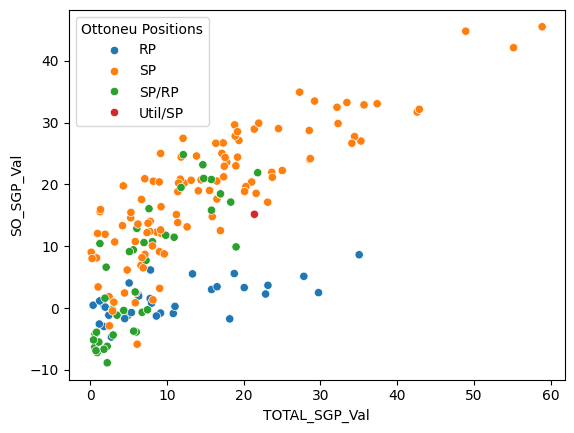

In [141]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 0.],x='TOTAL_SGP_Val',y='SO_SGP_Val',hue='Ottoneu Positions')

<Axes: xlabel='TOTAL_SGP_Val', ylabel='HR9_SGP_Val'>

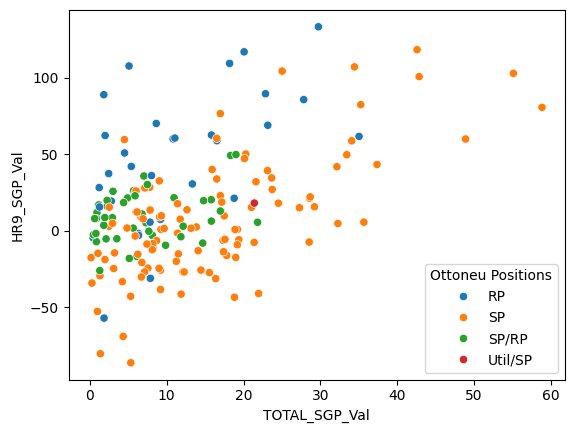

In [142]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 0.],x='TOTAL_SGP_Val',y='HR9_SGP_Val',hue='Ottoneu Positions')

<Axes: xlabel='TOTAL_SGP_Val', ylabel='ERA_SGP_Val'>

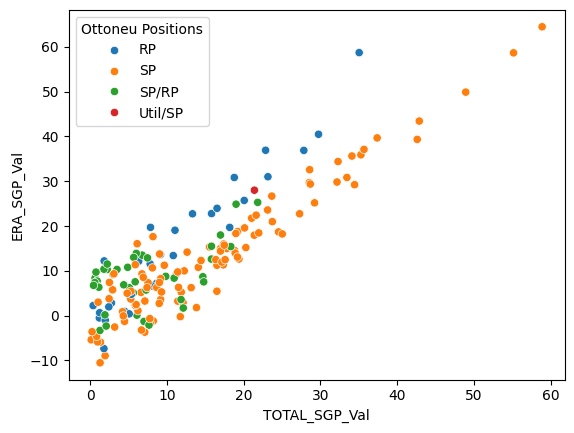

In [143]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 0.],x='TOTAL_SGP_Val',y='ERA_SGP_Val',hue='Ottoneu Positions')

<Axes: xlabel='TOTAL_SGP_Val', ylabel='WHIP_SGP_Val'>

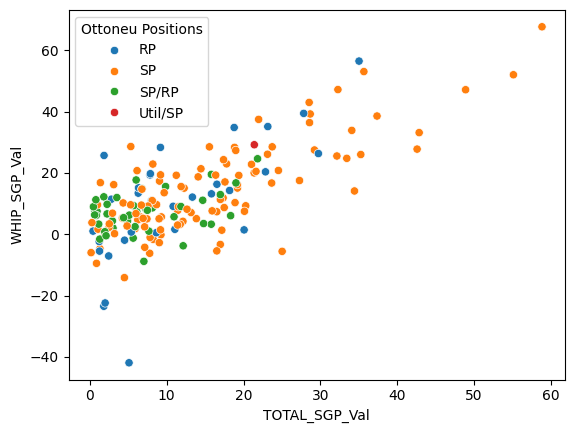

In [144]:
sns.scatterplot(Pitcher_Projections_df[Pitcher_Projections_df['TOTAL_SGP_Val'] >= 0.],x='TOTAL_SGP_Val',y='WHIP_SGP_Val',hue='Ottoneu Positions')

In [145]:
Hitter_Projections_df[Player_id_cols+['G','R','HR','OBP','SLG','R_SGP_Val','HR_SGP_Val','OBP_SGP_Val','SLG_SGP_Val','TOTAL_SGP','TOTAL_SGP_Val']].sort_values('TOTAL_SGP_Val',ascending=False)

,FG ID,Ottoneu ID,Name,Ottoneu Positions,Team,G,R,HR,OBP,SLG,R_SGP_Val,HR_SGP_Val,OBP_SGP_Val,SLG_SGP_Val,TOTAL_SGP,TOTAL_SGP_Val
76,15640,18312,Aaron Judge,OF,NYY,146.61860,108.94800,48.763900,0.422380,0.631321,44.576046,62.508198,96.725007,74.808816,10.638897,65.664948
217,19755,33600,Shohei Ohtani,Util/SP,LAD,151.88260,122.53540,47.803460,0.385290,0.606809,57.450318,58.034295,63.338388,66.216258,9.809387,60.545083
252,20123,23717,Juan Soto,OF,NYM,156.43260,109.55360,38.788260,0.410446,0.542005,45.066453,45.489038,90.767310,49.608044,8.764161,54.093779
444,25764,36668,Bobby Witt Jr.,SS,KCR,153.70480,104.13800,29.917040,0.352798,0.527193,43.048382,33.658816,40.234440,48.556948,6.610944,40.803788
157,18401,23327,Ronald Acuña Jr.,OF,ATL,146.62000,102.58700,29.850500,0.387239,0.505840,39.424988,30.240576,66.128874,37.574625,6.608555,40.789041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,19566,32765,Nathaniel Lowe,1B,CIN,41.35796,18.58780,4.407300,0.330432,0.376224,-35.661728,-23.611821,2.026400,-2.652794,-2.978704,-18.385028
44,13621,23582,Jeimer Candelario,1B/3B,LAA,30.80444,12.54332,3.553384,0.276589,0.346091,-40.556472,-21.514428,-3.854501,1.637947,-3.128488,-19.309520
1968,sa3025257,45715,Charlie Condon,1B,COL,37.80224,16.90796,4.336200,0.307453,0.391263,-37.022041,-23.733123,-3.049449,-1.148993,-3.141948,-19.392596
443,25714,36939,Blaine Crim,1B,COL,35.53538,15.89980,4.475554,0.307995,0.393905,-37.838436,-23.495375,-2.699276,-0.782658,-3.147329,-19.425809


In [146]:
import os, errno
# Create the directory and parent directories if they do not exist
os.makedirs(League_path+'/SGP_Val_'+SGP_Calc_date, exist_ok=True)
Hitter_csv_path = League_path+'/SGP_Val_'+SGP_Calc_date+'/Hitter_Projections_df.csv'
Pitcher_csv_path = League_path+'/SGP_Val_'+SGP_Calc_date+'/Pitcher_Projections_df.csv'
Hitter_Repl_csv_path = League_path+'/SGP_Val_'+SGP_Calc_date+'/Hitter_Replacement_df.csv'
Pitcher_Repl_csv_path = League_path+'/SGP_Val_'+SGP_Calc_date+'/Pitcher_Replacement_df.csv'
Hitter_Projections_df.to_csv(Hitter_csv_path,index=False)
Pitcher_Projections_df.to_csv(Pitcher_csv_path,index=False)
Hitting_Replacement_pivot_df.set_index('Ottoneu Positions').join(Hitting_Replacement_SGP_df).to_csv(Hitter_Repl_csv_path)
Pitching_Replacement_pivot_df.set_index('Ottoneu Positions').join(Pitching_Replacement_SGP_df).to_csv(Pitcher_Repl_csv_path)

In [147]:
def symlink_force(target, link_name):
    try:
        os.symlink(target, link_name)
    except OSError as e:
        if e.errno == errno.EEXIST:
            os.remove(link_name)
            os.symlink(target, link_name)
        else:
            raise e

In [148]:
if publish_Val_Update['Hitter']:
    Hitter_latest_link_name = League_path+'/Latest_Hitter_Proj.csv'
    symlink_force(Hitter_csv_path,Hitter_latest_link_name)
    Hitter_repl_link_name = League_path+'/Latest_Hitter_Repl.csv'
    symlink_force(Hitter_Repl_csv_path,Hitter_repl_link_name)

if publish_Val_Update['Pitcher']:
    Pitcher_latest_link_name = League_path+'/Latest_Pitcher_Proj.csv'
    symlink_force(Pitcher_csv_path,Pitcher_latest_link_name)
    Pitcher_repl_link_name = League_path+'/Latest_Pitcher_Repl.csv'
    symlink_force(Pitcher_Repl_csv_path,Pitcher_repl_link_name)